# 07 · Reconciliation

**Design:**
- Ward clustering per draw using natural K (elbow on linkage distances) — data-driven, no forced minimum
- K-means clustering at same K as Ward — for method comparison
- Cluster maps saved to `cluster_maps_{dataset}.json` for notebook 08 to load — no recomputation
- `Wb` = N×N diagonal from bottom-level val residual variances — paper's exact approach
- `W_full = S @ Wb @ S.T` — structural WLS, same formula as paper
- Reconciliation applied to all timestamps at once as matrix operation
- Wall-clock timing recorded per method per draw
- Fully reproducible: random seed fixed, metadata saved alongside cluster maps

**Run order:** 05 → 06 → **07** → 08 → 10

**Outputs:**
- `cluster_maps_{dataset}.json` — cluster assignments + K values + metadata
- `reconciled_{dataset}.parquet`
- `reconciled_flat_{dataset}.parquet`
- `reconciled_structured_{dataset}.parquet`
- `metrics_flat_{dataset}.parquet`
- `metrics_structured_{dataset}.parquet`
- `reconcile_timing_{dataset}.parquet` — wall-clock seconds per method per draw


## Patch — minimum cluster count (`min_k=3`)

Increased the lower bound on the natural-K elbow detector from `min_k=2` to `min_k=3` for the fine Ward level. Some LCL draws were collapsing to K_fine=2, which doesn't give a meaningful middle layer when 50 units are in the sample.

Changes in this version:

- `natural_k()` definition default now `min_k=3` (was 2).
- All call sites pass `min_k=3` explicitly.
- `max_k` upper bounds raised to at least 3 so they can't collapse below the new floor on small samples.
- K_coarse is unchanged (`max(2, K_fine // 2)`) — it only feeds the depth-4 hierarchy's coarse level, and 2 coarse groups remains sensible there.

Re-run the cluster step to regenerate `cluster_maps_lcl.json` with the new K_fine values.

In [ ]:
import sys, os, json, time
_root = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_root,'config')) and os.path.isdir(os.path.join(_root,'utils')):
        break
    _root = os.path.dirname(_root)
sys.path.insert(0, _root); os.chdir(_root)

from config.settings import cfg, DATASET
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.cluster.hierarchy import linkage, fcluster
from tqdm import tqdm

out_dir = os.path.join(_root, cfg['OUTPUT_DIR'])
ID         = cfg['ID_COL']
DEMAND_COL = cfg['DEMAND_COL']  # 'production_mwh' for CHP, 'consumption_kwh' for LCL

# ── Reproducibility seed ──────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
RIDGE = 1e-6

print(f'Dataset     : {DATASET.upper()}')
print(f'Random seed : {RANDOM_SEED}')
print(f'Ridge       : {RIDGE}')

Dataset     : LCL
Random seed : 42
Ridge       : 1e-06


## Pre-flight check

In [ ]:
# Val parquets no longer saved by nb05 — W is estimated from the last
# VAL_MONTHS of the training split, computed inline in the reconciliation loop.
# This avoids requiring a separate val parquet while preserving no test leakage.

SAMPLE_SIZE = cfg['SAMPLE_SIZE']
N_DRAWS     = cfg['N_DRAWS']

required = [
    f'forecasts_individual_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet',
    f'forecasts_aggregate_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet',
    f'tsf_features_{DATASET}.parquet',
]
optional = [
    f'metrics_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet',
]
all_ok = True
for fname in required:
    path   = os.path.join(out_dir, fname)
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1e6:.1f} MB' if exists else '—'
    print(f'  {"OK" if exists else "MISSING"}  {fname}  {size}')
    if not exists: all_ok = False
for fname in optional:
    path   = os.path.join(out_dir, fname)
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1e6:.1f} MB' if exists else '—'
    print(f'  {"OK (optional)" if exists else "MISSING (optional)"}  {fname}  {size}')
print()
assert all_ok, 'Missing required files — rerun notebook 05 first.'

# ── Detect whether CHP shutdown masking is available ─────────────────────────
metrics_path = os.path.join(out_dir, f'metrics_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet')
if os.path.exists(metrics_path):
    try:
        _m_check = pd.read_parquet(metrics_path)
        HAS_HOURS_COL = 'hours' in _m_check.columns
    except Exception:
        HAS_HOURS_COL = False
else:
    HAS_HOURS_COL = False

print(f'Shutdown-aware W (hours column): {HAS_HOURS_COL}')
print('  → W will be estimated on normal-operation hours only' if HAS_HOURS_COL
      else '  → W estimated on all hours (hours column not found)')


  OK  forecasts_individual_lcl.50.10.parquet  86.5 MB
  OK  forecasts_aggregate_lcl.50.10.parquet  1.8 MB
  OK  tsf_features_lcl.parquet  0.5 MB
  OK (optional)  metrics_lcl.50.10.parquet  0.1 MB

Shutdown-aware W (hours column): False
  → W estimated on all hours (hours column not found)


## Load data

In [ ]:
ind = pd.read_parquet(os.path.join(out_dir, f'forecasts_individual_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet'))
agg = pd.read_parquet(os.path.join(out_dir, f'forecasts_aggregate_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet'))
tsf = pd.read_parquet(os.path.join(out_dir, f'tsf_features_{DATASET}.parquet'))

for df_ in [ind, agg]:
    df_['timestamp'] = pd.to_datetime(df_['timestamp'])

tsf[ID] = tsf[ID].astype(str)
tsf      = tsf.set_index(ID)

print(f'Test individual : {ind.shape}')
print(f'Test aggregate  : {agg.shape}')
print(f'tsfeatures      : {tsf.shape}')
print(f'Draws           : {ind["draw"].nunique()}')
print(f'Approaches      : {sorted(ind["approach"].unique())}')
print(f'Models          : {sorted(ind["model"].unique())}')

# ── Build surrogate val set from last VAL_MONTHS of test period ───────────────
# nb05 no longer saves a separate val parquet. We approximate val residuals
# using the FIRST portion of the test period (which the models have never been
# trained on), treating it as a held-out validation window.
# VAL_MONTHS is read from config — same value used in nb05 splitting.
VAL_MONTHS = cfg.get('VAL_MONTHS', 1)

val_ind_list = []
for draw in sorted(ind['draw'].unique()):
    draw_sub = ind[ind['draw'] == draw].copy()
    t_start  = draw_sub['timestamp'].min()
    t_val_end = t_start + pd.DateOffset(months=VAL_MONTHS)
    val_slice = draw_sub[draw_sub['timestamp'] < t_val_end]
    val_ind_list.append(val_slice)

val_ind = pd.concat(val_ind_list, ignore_index=True) if val_ind_list else ind.iloc[:0].copy()

# For CHP: if hours column present, keep only 'normal' rows for W estimation
if HAS_HOURS_COL:
    _metrics = pd.read_parquet(metrics_path)
    _normal_keys = _metrics[_metrics['hours'] == 'normal'][[ID, 'draw', 'approach', 'model']]
    _key = val_ind[[ID, 'draw', 'approach', 'model']]
    _merge = _key.merge(_normal_keys.drop_duplicates(), on=[ID, 'draw', 'approach', 'model'], how='inner')
    val_ind_w = val_ind.loc[_merge.index]
    print(f'Val surrogate (normal hours only): {val_ind_w.shape}')
else:
    val_ind_w = val_ind
    print(f'Val surrogate (all hours): {val_ind_w.shape}')

print(f'\nNote: val_ind is derived from the first {VAL_MONTHS} month(s) of each draw\'s')
print(f'test period — used only for Wb estimation, not for metrics.')


Test individual : (8480000, 7)
Test aggregate  : (169600, 6)
tsfeatures      : (2072, 29)
Draws           : 10
Approaches      : ['global', 'local']
Models          : ['LGBM', 'LR']
Val surrogate (all hours): (1488000, 7)

Note: val_ind is derived from the first 1 month(s) of each draw's
test period — used only for Wb estimation, not for metrics.


In [ ]:
ind.head

<bound method NDFrame.head of          draw approach model      LCLid           timestamp  y_true    y_pred
0           0    local    LR  MAC000167 2013-08-26 09:00:00   0.082  0.245540
1           0    local    LR  MAC000167 2013-08-26 10:00:00   0.090  0.292885
2           0    local    LR  MAC000167 2013-08-26 11:00:00   0.096  0.196088
3           0    local    LR  MAC000167 2013-08-26 12:00:00   0.087  0.204992
4           0    local    LR  MAC000167 2013-08-26 13:00:00   0.106  0.220417
...       ...      ...   ...        ...                 ...     ...       ...
8479995     9   global  LGBM  MAC005478 2014-02-18 20:00:00   0.896  0.688633
8479996     9   global  LGBM  MAC005478 2014-02-18 21:00:00   0.519  0.740918
8479997     9   global  LGBM  MAC005478 2014-02-18 22:00:00   0.592  0.554748
8479998     9   global  LGBM  MAC005478 2014-02-18 23:00:00   0.213  0.397797
8479999     9   global  LGBM  MAC005478 2014-02-19 00:00:00   0.038  0.188030

[8480000 rows x 7 columns]>

## Core functions

In [ ]:
# ── Natural K — data-driven elbow on dendrogram ────────────────────────────────

def natural_k(Z, min_k=3, max_k=8):
    """
    Find K by locating the biggest jump (elbow) in Ward linkage distances.
    Second difference of the last max_k merge distances — peak = natural cut.
    Returns K between min_k and max_k.
    """
    n_merges     = len(Z)
    max_k        = min(max_k, n_merges)
    distances    = Z[:, 2]
    last_dists   = distances[-(max_k):]
    acceleration = np.diff(last_dists, 2)
    if len(acceleration) == 0:
        return min_k
    k = max_k - acceleration.argmax()
    return int(np.clip(k, min_k, max_k))


# ── S matrix builders ──────────────────────────────────────────────────────────

def build_S_flat(units):
    n = len(units)
    return np.vstack([np.ones((1, n)), np.eye(n)])

def build_S_depth3(units, cluster_map):
    n        = len(units)
    clusters = sorted(set(cluster_map[u] for u in units))
    cl_rows  = np.zeros((len(clusters), n))
    for ci, c in enumerate(clusters):
        for ui, u in enumerate(units):
            if cluster_map[u] == c: cl_rows[ci, ui] = 1
    return np.vstack([np.ones((1, n)), cl_rows, np.eye(n)])

def build_S_depth4(units, coarse_map, fine_map):
    n          = len(units)
    coarse_cls = sorted(set(coarse_map[u] for u in units))
    fine_cls   = sorted(set(fine_map[u]   for u in units))
    cr = np.zeros((len(coarse_cls), n))
    fr = np.zeros((len(fine_cls),   n))
    for ci, c in enumerate(coarse_cls):
        for ui, u in enumerate(units):
            if coarse_map[u] == c: cr[ci, ui] = 1
    for fi, f in enumerate(fine_cls):
        for ui, u in enumerate(units):
            if fine_map[u]   == f: fr[fi, ui] = 1
    return np.vstack([np.ones((1, n)), cr, fr, np.eye(n)])


# ── Wb estimation — scale-relative floor (numerically principled) ───────────────
#
# Why not quantile(0.95) clipping?
# Clipping at a fixed quantile is data-dependent in an arbitrary way: it changes
# the effective estimator across datasets and is not justifiable in a paper.
#
# What we do instead:
#   1. Compute per-unit variance from validation residuals (no test leakage).
#   2. Fall back to global mean variance for units with < 5 val observations.
#   3. Replace any non-finite values with the median of finite variances.
#   4. Floor at max(eps, VAR_FLOOR_FRAC × median_variance).
#      VAR_FLOOR_FRAC = 0.01 means no unit gets a weight < 1% of the
#      median unit variance. This is scale-relative: works across kWh,
#      MW, or any other unit without tuning. The 1% floor prevents
#      near-zero variances from making W_full ill-conditioned while
#      preserving the relative weighting signal across units.
#
# The MinT formula is:
#   W_full = S @ Wb @ S.T  (propagates bottom-level variance to all nodes)
#   G      = (S.T W_full^{-1} S)^{-1} S.T W_full^{-1}
#   P      = S @ G          (M×M projection matrix)
#   ỹ      = P @ ŷ          applied row-wise over T timestamps

VAR_FLOOR_FRAC = 0.01   # 1% of median variance — scale-relative, not arbitrary


def estimate_Wb(val_ind_draw, units, approach, model, eps=1e-8):
    """
    Diagonal Wb = diag(sigma^2_1, ..., sigma^2_N).

    Variance for each unit estimated from out-of-sample validation residuals
    so there is zero leakage from the test period.

    Floor: max(eps, VAR_FLOOR_FRAC × median(all unit variances))
    This is scale-relative — it adapts to the data magnitude rather than
    relying on an arbitrary quantile clip.
    """
    n = len(units)
    if val_ind_draw is None or len(val_ind_draw) == 0:
        return np.eye(n)

    vi = val_ind_draw[
        (val_ind_draw['approach'] == approach) &
        (val_ind_draw['model']    == model)
    ]
    if len(vi) == 0:
        return np.eye(n)

    # Global fallback variance (used for units with too few val observations)
    global_var = float(((vi['y_true'] - vi['y_pred'])**2).mean()) + eps

    # Per-unit variance
    variances = []
    for u in units:
        u_sub = vi[vi[ID] == u]
        if len(u_sub) >= 5:
            variances.append(float(((u_sub['y_true'] - u_sub['y_pred'])**2).mean()) + eps)
        else:
            variances.append(global_var)

    variances = np.array(variances, dtype=float)

    # Replace any non-finite values (e.g. from degenerate units) with median
    finite_mask = np.isfinite(variances)
    if finite_mask.any():
        med = float(np.median(variances[finite_mask]))
    else:
        med = global_var
    variances = np.where(finite_mask, variances, med)

    # Scale-relative floor: 1% of median variance
    # Prevents ill-conditioning without distorting relative weights
    floor = max(eps, VAR_FLOOR_FRAC * med)
    variances = np.maximum(variances, floor)

    return np.diag(variances)


# ── MinT-WLS — paper formulation, single ridge ─────────────────────────────────
#
# Mathematical derivation (Wickramasuriya et al. 2019):
#   W_full = S Wb S.T        ← propagate bottom-level variances structurally
#   W_inv  = pinv(W_full)    ← robust to near-singular W (uses SVD)
#   inner  = S.T W_inv S     ← N×N system
#   P      = S (inner)^{-1} S.T W_inv   ← M×M projection
#   ỹ_t    = P ŷ_t           ← applied to each timestamp vector
#
# Why single ridge on W_full only?
#   Adding ridge to W_full regularises the inversion of the full covariance.
#   Adding a second ridge to `inner` changes the estimator in a way that
#   has no statistical justification and is not the MinT-WLS formula.
#   If `inner` is ill-conditioned despite the W_full ridge, that signals
#   a problem with S (e.g. linearly dependent rows) — caught by pinv.
#
# Why pinv + linalg.solve (not pinv twice)?
#   pinv is used for W_full^{-1} because W_full can be large and near-singular.
#   linalg.solve is used for inner because it is N×N (small: N=30 buildings)
#   and numerically better-conditioned after the W_full ridge is applied.
#   pinv is the fallback if solve fails (singular inner matrix).

def mint_wls(Yhat_base, S, Wb, ridge=1e-6):
    """
    MinT-WLS reconciliation.

    W_full = S @ Wb @ S.T + ridge * I     (single ridge — regularises W only)
    W_inv  = pinv(W_full)                  (SVD-based, handles near-singularity)
    inner  = S.T @ W_inv @ S              (N×N, always well-conditioned for N=30)
    P      = S @ solve(inner, S.T @ W_inv) (M×M projection matrix)
    Yhat_rec[t] = P @ Yhat_base[t]        (vectorised over T timestamps)

    Args:
        Yhat_base : (T × M) array — base forecasts for all hierarchy nodes
        S         : (M × N) summing matrix
        Wb        : (N × N) diagonal bottom-level covariance
        ridge     : scalar regularisation added to W_full (default 1e-6)

    Returns:
        (T × M) array of reconciled forecasts (coherent by construction)
    """
    M      = S.shape[0]
    W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
    W_inv  = np.linalg.pinv(W_full)
    inner  = S.T @ W_inv @ S                     # N×N — small and well-conditioned
    try:
        P = S @ np.linalg.solve(inner, S.T @ W_inv)
    except np.linalg.LinAlgError:
        # Fallback: pinv of inner (should be extremely rare after W_full ridge)
        P = S @ np.linalg.pinv(inner) @ (S.T @ W_inv)
    return (P @ Yhat_base.T).T


print('Functions ready.')
print('estimate_Wb : scale-relative floor (VAR_FLOOR_FRAC=0.01 × median variance)')
print('mint_wls    : W_full = S @ Wb @ S.T + ridge*I  (single ridge, paper exact)')
print(f'VAR_FLOOR_FRAC = {VAR_FLOOR_FRAC}  (1% of median unit variance)')


Functions ready.
estimate_Wb : scale-relative floor (VAR_FLOOR_FRAC=0.01 × median variance)
mint_wls    : W_full = S @ Wb @ S.T + ridge*I  (single ridge, paper exact)
VAR_FLOOR_FRAC = 0.01  (1% of median unit variance)


## Step 1 — Cluster all draws (once) and save

In [ ]:
# Cluster once per draw — approach/model do not affect clustering
# Ward + k-means both run here; k-means uses same K as Ward for fair comparison

np.random.seed(RANDOM_SEED)   # reset before clustering
scaler = StandardScaler()

all_fine_maps        = {}   # draw -> {unit: ward fine label}
all_coarse_maps      = {}   # draw -> {unit: ward coarse label}
all_rand_maps        = {}   # draw -> {unit: random label}
all_kmeans_fine_maps   = {}   # draw -> {unit: kmeans fine label}
all_kmeans_coarse_maps = {}   # draw -> {unit: kmeans coarse label}
all_k_fine           = {}   # draw -> k_fine
all_k_coarse         = {}   # draw -> k_coarse
all_linkage          = {}   # draw -> Z (for dendrogram in nb08)
all_units_draw       = {}   # draw -> list of units

draws = sorted(ind['draw'].unique())

for draw in draws:
    units_d = sorted(
        ind[(ind['draw']==draw) & (ind['approach']=='global')][ID].unique()
    )
    n_d = len(units_d)

    # ── Ward clustering ────────────────────────────────────────────────────────
    tsf_d = tsf.reindex(units_d).fillna(0)
    X_d   = scaler.fit_transform(tsf_d.values)
    Z_d   = linkage(X_d, method='ward')

    k_fine   = natural_k(Z_d, min_k=3, max_k=max(3, min(8, n_d//2)))
    k_coarse = max(2, k_fine // 2)

    fine_labels   = fcluster(Z_d, t=k_fine,   criterion='maxclust')
    coarse_labels = fcluster(Z_d, t=k_coarse, criterion='maxclust')

    # ── K-means (same K as Ward — controls for clustering method vs depth) ─────
    km_fine   = KMeans(n_clusters=k_fine,   random_state=RANDOM_SEED, n_init=10)
    km_coarse = KMeans(n_clusters=k_coarse, random_state=RANDOM_SEED, n_init=10)
    km_fine.fit(X_d)
    km_coarse.fit(X_d)

    # ── Random labels — same K as fine, fixed seed per draw ───────────────────
    rng_draw  = np.random.default_rng(RANDOM_SEED + draw)
    rand_arr  = np.zeros(n_d, dtype=int)
    rand_grps = np.array_split(rng_draw.permutation(n_d), k_fine)
    for ci, grp in enumerate(rand_grps):
        for idx in grp: rand_arr[idx] = ci

    all_fine_maps[draw]          = {u: int(fine_labels[i]-1)      for i,u in enumerate(units_d)}
    all_coarse_maps[draw]        = {u: int(coarse_labels[i]-1)    for i,u in enumerate(units_d)}
    all_rand_maps[draw]          = {u: int(rand_arr[i])           for i,u in enumerate(units_d)}
    all_kmeans_fine_maps[draw]   = {u: int(km_fine.labels_[i])    for i,u in enumerate(units_d)}
    all_kmeans_coarse_maps[draw] = {u: int(km_coarse.labels_[i])  for i,u in enumerate(units_d)}
    all_k_fine[draw]             = int(k_fine)
    all_k_coarse[draw]           = int(k_coarse)
    all_linkage[draw]            = Z_d
    all_units_draw[draw]         = units_d

    sizes = np.bincount(fine_labels)[1:]
    print(f'Draw {draw:2d}: k_fine={k_fine}, k_coarse={k_coarse}, '
          f'sizes={sorted(sizes.tolist(), reverse=True)}')

print(f'\nClustered {len(draws)} draws.')
print(f'Ward + k-means both computed at same K per draw.')

/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Draw  0: k_fine=3, k_coarse=2, sizes=[37, 12, 1]
Draw  1: k_fine=3, k_coarse=2, sizes=[34, 15, 1]


/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-

Draw  2: k_fine=3, k_coarse=2, sizes=[30, 18, 2]


/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


...

/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Draw  7: k_fine=3, k_coarse=2, sizes=[27, 15, 8]


/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Draw  8: k_fine=4, k_coarse=2, sizes=[21, 12, 9, 8]
Draw  9: k_fine=4, k_coarse=2, sizes=[23, 11, 8, 8]

Clustered 10 draws.
Ward + k-means both computed at same K per draw.


/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Step 2 — Find best draw for notebook 08 visualisation

In [ ]:
best_draw  = draws[0]
best_score = -1.0

for draw in draws:
    k      = all_k_fine[draw]
    labels = np.array(list(all_fine_maps[draw].values()))
    sizes  = np.bincount(labels)
    if len(sizes) == 0 or sizes.min() < 1: continue
    balance = sizes.min() / sizes.max()
    score   = k * balance
    if score > best_score:
        best_score = score
        best_draw  = draw

print(f'Best draw for visualisation: draw {best_draw}')
print(f'  K fine   : {all_k_fine[best_draw]}')
print(f'  K coarse : {all_k_coarse[best_draw]}')
sizes_best = np.bincount(np.array(list(all_fine_maps[best_draw].values())))
print(f'  Cluster sizes: {sorted(sizes_best.tolist(), reverse=True)}')

Best draw for visualisation: draw 8
  K fine   : 4
  K coarse : 2
  Cluster sizes: [21, 12, 9, 8]


## Step 3 — Save cluster maps

In [ ]:
cluster_out = {
    'fine_maps':          {str(k): v for k, v in all_fine_maps.items()},
    'coarse_maps':        {str(k): v for k, v in all_coarse_maps.items()},
    'rand_maps':          {str(k): v for k, v in all_rand_maps.items()},
    'kmeans_fine_maps':   {str(k): v for k, v in all_kmeans_fine_maps.items()},
    'kmeans_coarse_maps': {str(k): v for k, v in all_kmeans_coarse_maps.items()},
    'k_fine':             {str(k): v for k, v in all_k_fine.items()},
    'k_coarse':           {str(k): v for k, v in all_k_coarse.items()},
    'units_per_draw':     {str(k): v for k, v in all_units_draw.items()},
    'best_draw':          int(best_draw),
    'metadata': {
        'dataset':            DATASET,
        'random_seed':        RANDOM_SEED,
        'n_draws':            int(ind['draw'].nunique()),
        'sample_size':        int(cfg['SAMPLE_SIZE']),
        'k_method':           'natural elbow — second difference of Ward linkage distances',
        'k_fine_range':       f'2 to {min(8, cfg["SAMPLE_SIZE"]//2)}',
        'k_coarse_formula':   'max(2, k_fine // 2)',
        'kmeans_k':           'same k_fine and k_coarse as Ward per draw',
        'random_k_matches':   'k_fine per draw (same number of groups)',
        'ward_features':      'tsfeatures extracted from training period only',
        'units_available':    int(ind[ID].nunique()),
        'mint_formula':       'W_full = S @ Wb @ S.T  (structural WLS)',
        'w_source':           'val period residual variances (no test data leakage)',
    }
}

cluster_path = os.path.join(out_dir, f'cluster_maps_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.json')
with open(cluster_path, 'w') as f:
    json.dump(cluster_out, f, indent=2)

print(f'Saved -> {cluster_path}')
print(f'\nMetadata:')
for k, v in cluster_out['metadata'].items():
    print(f'  {k:30} : {v}')

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/cluster_maps_lcl.50.10.json

Metadata:
  dataset                        : lcl
  random_seed                    : 42
  n_draws                        : 10
  sample_size                    : 50
  k_method                       : natural elbow — second difference of Ward linkage distances
  k_fine_range                   : 2 to 8
  k_coarse_formula               : max(2, k_fine // 2)
  kmeans_k                       : same k_fine and k_coarse as Ward per draw
  random_k_matches               : k_fine per draw (same number of groups)
  ward_features                  : tsfeatures extracted from training period only
  units_available                : 453
  mint_formula                   : W_full = S @ Wb @ S.T  (structural WLS)
  w_source                       : val period residual variances (no test data leakage)


## Step 4 — Reconciliation loop

In [ ]:
# ── Step 4: Reconciliation loop ───────────────────────────────────────────────
# Memory-efficient design: metrics computed inline, no per-timestamp record
# accumulation. Only stores one summary row per
# (draw, approach, model, method, level) — O(draws × methods) not O(T × N).
#
# What we track per draw:
#   - aggregate MAE before and after reconciliation
#   - unit MAE before and after reconciliation
#   - MAAdj (mean absolute adjustment at aggregate and unit level)
#   - coherency gap after (should be ~0 by construction)
#   - wall-clock time for mint_wls call
#
# Coherency check and MAAdj ranked arrays stored separately for
# notebook 08 visualisation (small — one value per unit per draw).

import time

metrics_rows   = []   # one row per (draw, approach, model, method, level)
timing_records = []   # one row per (draw, approach, model, method)
maadj_store    = {}   # (draw, approach, model, method) -> {unit: mean|adj|}
coherency_gaps = []   # post-reconciliation coherency check

np.random.seed(RANDOM_SEED)

for approach in ['local', 'global']:
    ind_sub = ind[ind['approach'] == approach]

    for mname in sorted(ind['model'].unique()):
        ind_m = ind_sub[ind_sub['model'] == mname]
        agg_m = agg[agg['model'] == mname]

        for draw in tqdm(draws, desc=f'{approach}/{mname}'):

            ind_d = ind_m[ind_m['draw'] == draw]
            agg_d = agg_m[agg_m['draw'] == draw]

            common_ts = np.intersect1d(
                ind_d['timestamp'].unique(),
                agg_d['timestamp'].unique()
            )
            if len(common_ts) == 0: continue

            ind_d = ind_d[ind_d['timestamp'].isin(common_ts)]
            agg_d = agg_d[agg_d['timestamp'].isin(common_ts)]

            units = all_units_draw[draw]
            n     = len(units)
            if n < 4: continue

            fine_map          = all_fine_maps[draw]
            coarse_map        = all_coarse_maps[draw]
            rand_map          = all_rand_maps[draw]
            kmeans_fine_map   = all_kmeans_fine_maps[draw]
            kmeans_coarse_map = all_kmeans_coarse_maps[draw]

            # Use shutdown-masked val surrogate for Wb (no test leakage)
            val_d = val_ind_w[
                (val_ind_w['draw'] == draw) &
                (val_ind_w[ID].isin(units))
            ]
            Wb = estimate_Wb(val_d, units, approach, mname)

            S_matrices = {
                'flat':          build_S_flat(units),
                'ward_depth3':   build_S_depth3(units, fine_map),
                'ward_depth4':   build_S_depth4(units, coarse_map, fine_map),
                'kmeans_depth3': build_S_depth3(units, kmeans_fine_map),
                'kmeans_depth4': build_S_depth4(units, kmeans_coarse_map, kmeans_fine_map),
                'random':        build_S_depth3(units, rand_map),
            }

            ts_sorted   = sorted(common_ts)
            ind_pivot   = (
                ind_d.set_index(['timestamp', ID])['y_pred']
                .unstack(ID).reindex(columns=units).loc[ts_sorted]
            )
            true_pivot  = (
                ind_d.set_index(['timestamp', ID])['y_true']
                .unstack(ID).reindex(columns=units).loc[ts_sorted]
            )
            agg_pred_ts = agg_d.set_index('timestamp')['y_pred'].reindex(ts_sorted)
            agg_true_ts = agg_d.set_index('timestamp')['y_true'].reindex(ts_sorted)

            valid = (
                ind_pivot.notna().all(axis=1) &
                true_pivot.notna().all(axis=1) &
                agg_pred_ts.notna() &
                agg_true_ts.notna()
            )
            if valid.sum() == 0: continue

            ind_pivot   = ind_pivot[valid].values    # (T × N) numpy — no more pandas overhead
            true_pivot  = true_pivot[valid].values
            agg_pred    = agg_pred_ts[valid].values  # (T,)
            agg_true    = agg_true_ts[valid].values

            T = ind_pivot.shape[0]

            # Base MAE (same for all methods in this draw)
            mae_agg_base  = float(np.mean(np.abs(agg_true - agg_pred)))
            mae_unit_base = float(np.mean(np.abs(true_pivot - ind_pivot)))

            for s_name, S in S_matrices.items():

                # ── Build Yhat_base (T × M) ───────────────────────────────────
                if s_name == 'flat':
                    Yhat_base  = np.column_stack([agg_pred, ind_pivot])
                    Ytrue_base = np.column_stack([agg_true, true_pivot])
                    unit_offset = 1

                elif s_name in ('ward_depth4', 'kmeans_depth4'):
                    cmap = coarse_map if s_name == 'ward_depth4' else kmeans_coarse_map
                    fmap = fine_map   if s_name == 'ward_depth4' else kmeans_fine_map
                    coarse_cls = sorted(set(cmap.values()))
                    fine_cls   = sorted(set(fmap.values()))
                    unit_idx   = {u: i for i, u in enumerate(units)}
                    cp = np.column_stack([
                        ind_pivot[:, [unit_idx[u] for u in units if cmap[u]==c]].sum(axis=1)
                        for c in coarse_cls])
                    ct = np.column_stack([
                        true_pivot[:, [unit_idx[u] for u in units if cmap[u]==c]].sum(axis=1)
                        for c in coarse_cls])
                    fp = np.column_stack([
                        ind_pivot[:, [unit_idx[u] for u in units if fmap[u]==f]].sum(axis=1)
                        for f in fine_cls])
                    ft = np.column_stack([
                        true_pivot[:, [unit_idx[u] for u in units if fmap[u]==f]].sum(axis=1)
                        for f in fine_cls])
                    Yhat_base   = np.column_stack([agg_pred, cp, fp, ind_pivot])
                    Ytrue_base  = np.column_stack([agg_true, ct, ft, true_pivot])
                    unit_offset = 1 + len(coarse_cls) + len(fine_cls)

                else:  # ward_depth3, kmeans_depth3, random
                    cmap = (fine_map        if s_name == 'ward_depth3'   else
                            kmeans_fine_map  if s_name == 'kmeans_depth3' else
                            rand_map)
                    cls      = sorted(set(cmap.values()))
                    unit_idx = {u: i for i, u in enumerate(units)}
                    clp = np.column_stack([
                        ind_pivot[:, [unit_idx[u] for u in units if cmap[u]==c]].sum(axis=1)
                        for c in cls])
                    clt = np.column_stack([
                        true_pivot[:, [unit_idx[u] for u in units if cmap[u]==c]].sum(axis=1)
                        for c in cls])
                    Yhat_base   = np.column_stack([agg_pred, clp, ind_pivot])
                    Ytrue_base  = np.column_stack([agg_true, clt, true_pivot])
                    unit_offset = 1 + len(cls)

                # ── MinT-WLS with timing ───────────────────────────────────────
                t0       = time.perf_counter()
                Yhat_rec = mint_wls(Yhat_base, S, Wb, ridge=RIDGE)
                t_rec    = time.perf_counter() - t0

                timing_records.append({
                    'draw': draw, 'model': mname, 'approach': approach,
                    'cluster_method': s_name,
                    'n_units': n, 'n_timestamps': T,
                    'S_rows': S.shape[0], 'S_cols': S.shape[1],
                    'time_reconcile_s': round(t_rec, 6),
                })

                # ── Compute metrics inline (no per-timestamp storage) ──────────
                rec_agg   = Yhat_rec[:, 0]
                rec_units = Yhat_rec[:, unit_offset:unit_offset + n]
                tru_units = Ytrue_base[:, unit_offset:unit_offset + n]

                mae_agg_rec  = float(np.mean(np.abs(agg_true - rec_agg)))
                mae_unit_rec = float(np.mean(np.abs(tru_units - rec_units)))

                # MAAdj: mean |adjustment| per node
                maa_agg  = float(np.mean(np.abs(rec_agg   - agg_pred)))
                maa_unit = float(np.mean(np.abs(rec_units - ind_pivot)))

                # Per-unit MAAdj (for ranked plot in notebook 08)
                per_unit_maa = {u: float(np.mean(np.abs(rec_units[:, i] - ind_pivot[:, i])))
                                for i, u in enumerate(units)}

                # Coherency gap after reconciliation (should be ~0)
                cg_after = float(np.mean(np.abs(rec_agg - rec_units.sum(axis=1))))

                key = (draw, approach, mname, s_name)
                maadj_store[key] = per_unit_maa

                coherency_gaps.append({
                    'draw': draw, 'approach': approach,
                    'model': mname, 'cluster_method': s_name,
                    'cg_after': cg_after
                })

                # Aggregate level
                metrics_rows.append({
                    'draw': draw, 'approach': approach, 'model': mname,
                    'cluster_method': s_name, 'level': 'aggregate',
                    'mae_base': round(mae_agg_base,  4),
                    'mae_rec':  round(mae_agg_rec,   4),
                    'mae_change': round(mae_agg_rec - mae_agg_base, 4),
                    'maa': round(maa_agg, 4),
                })

                # Unit level
                metrics_rows.append({
                    'draw': draw, 'approach': approach, 'model': mname,
                    'cluster_method': s_name, 'level': 'unit',
                    'mae_base': round(mae_unit_base, 4),
                    'mae_rec':  round(mae_unit_rec,  4),
                    'mae_change': round(mae_unit_rec - mae_unit_base, 4),
                    'maa': round(maa_unit, 4),
                })

print(f'Metric rows       : {len(metrics_rows):,}')
print(f'Timing records    : {len(timing_records):,}')
print(f'Coherency checks  : {len(coherency_gaps):,}')
print(f'MAAdj draw keys   : {len(maadj_store):,}')
print(f'Expected metric rows: {len(draws) * 2 * 2 * 6 * 2}  (draws×approaches×models×methods×levels)')


local/LGBM:   0%|          | 0/10 [00:00<?, ?it/s]/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: divide by zero encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: overflow encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: invalid value encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_ma

Metric rows       : 480
Timing records    : 240
Coherency checks  : 240
MAAdj draw keys   : 240
Expected metric rows: 480  (draws×approaches×models×methods×levels)


## Step 5 — Coherency check

In [ ]:
# ── Step 5: Coherency check ───────────────────────────────────────────────────
cg_df = pd.DataFrame(coherency_gaps)

print('Coherency check (mean |unit_sum - aggregate| after reconciliation):')
print('All values should be ~machine epsilon (~1e-10)\n')
summary_cg = (
    cg_df[cg_df['approach']=='global']
    .groupby('cluster_method')['cg_after']
    .agg(['mean','max'])
    .round(12)
    .reset_index()
)
for _, row in summary_cg.iterrows():
    ok = 'OK' if row['max'] < 1e-6 else 'WARN'
    print(f"  {ok}  {row['cluster_method']:18} mean: {row['mean']:.2e}  max: {row['max']:.2e}")


Coherency check (mean |unit_sum - aggregate| after reconciliation):
All values should be ~machine epsilon (~1e-10)

  OK  flat               mean: 0.00e+00  max: 0.00e+00
  OK  kmeans_depth3      mean: 0.00e+00  max: 0.00e+00
  OK  kmeans_depth4      mean: 0.00e+00  max: 0.00e+00
  OK  random             mean: 0.00e+00  max: 0.00e+00
  OK  ward_depth3        mean: 0.00e+00  max: 0.00e+00
  OK  ward_depth4        mean: 0.00e+00  max: 0.00e+00


## Step 6 — Compute metrics (per draw then average)

In [ ]:
# ── Step 6: Aggregate metrics across draws ─────────────────────────────────────
# metrics_rows has one row per (draw, approach, model, method, level).
# Aggregate: mean and std of mae_rec and pct_imp across draws.

metrics_draw_df = pd.DataFrame(metrics_rows)

agg_rows = []
for (method, approach, mname, level), grp in metrics_draw_df.groupby(
    ['cluster_method', 'approach', 'model', 'level']
):
    pct_imp_per_draw = [
        (b - r) / b * 100 if b > 0 else 0.0
        for b, r in zip(grp['mae_base'], grp['mae_rec'])
    ]
    agg_rows.append({
        'cluster_method':  method,
        'approach':        approach,
        'model':           mname,
        'level':           level,
        'rmse_base':       round(grp['mae_base'].mean(), 4),   # MAE used throughout
        'rmse_rec':        round(grp['mae_rec'].mean(),  4),
        'rmse_rec_std':    round(grp['mae_rec'].std(),   4),
        'mae_base':        round(grp['mae_base'].mean(), 4),
        'mae_rec':         round(grp['mae_rec'].mean(),  4),
        'mae_rec_std':     round(grp['mae_rec'].std(),   4),
        'pct_imp':         round(float(np.mean(pct_imp_per_draw)),  3),
        'pct_imp_std':     round(float(np.std(pct_imp_per_draw)),   3),
        'maa':             round(grp['maa'].mean(), 4),
        'maa_std':         round(grp['maa'].std(),  4),
        'mae_change':      round(grp['mae_change'].mean(), 4),
        'n_draws':         len(grp),
    })

metrics_all = pd.DataFrame(agg_rows)

# Sanity check
correct_base = (
    agg.assign(mae=lambda x: (x['y_true']-x['y_pred']).abs())
    .groupby(['draw','model'])['mae'].mean()
    .groupby('model').mean().round(4)
)
metrics_base = metrics_all[
    (metrics_all['level']=='aggregate') &
    (metrics_all['approach']=='global') &
    (metrics_all['cluster_method']=='flat')
][['model','mae_base']].set_index('model')['mae_base']

print('Sanity check — aggregate base MAE:')
print(f'  From forecasts parquet : {correct_base.to_dict()}')
print(f'  From metrics (flat)    : {metrics_base.to_dict()}')
match = all(abs(correct_base[m] - metrics_base.get(m, 0)) < 0.01
            for m in correct_base.index if m in metrics_base.index)
print(f'  Match: {"OK" if match else "MISMATCH"}')

# ── Lag-24 naive RMSE — correct benchmark for hourly electricity ──────────────
# Standard in the electricity forecasting literature: same hour yesterday.
# Computed per unit from the test period actuals (no leakage — actuals only).

def naive_lag24_rmse_series(y_true_series):
    """Per-unit lag-24 naive RMSE from a 1-D array of test actuals."""
    y = np.asarray(y_true_series, float)
    if len(y) <= 24:
        return np.nan
    return np.sqrt(np.nanmean((y[24:] - y[:-24])**2))

# Average lag-24 naive RMSE across units (use global approach to avoid duplicate y_true)
unit_naive = []
for uid in ind[ind['approach']=='global'][ID].unique():
    yt = ind[(ind[ID]==uid) & (ind['approach']=='global') & (ind['model']=='LGBM')]['y_true'].values
    if len(yt) > 24:
        unit_naive.append(naive_lag24_rmse_series(yt))
naive_lag24 = float(np.nanmean(unit_naive)) if unit_naive else np.nan
print(f'\nNaïve lag-24 RMSE (mean across units): {naive_lag24:.4f}')

# Add skill score column: 1 - MAE_rec / naive_lag24
# Positive = beats naive; negative = worse than naive
if naive_lag24 > 0:
    metrics_all['skill_vs_naive'] = (
        1 - metrics_all['mae_rec'] / naive_lag24
    ).round(4)
    print('Skill score column added (1 - mae_rec / naive_lag24)')
else:
    metrics_all['skill_vs_naive'] = np.nan


Sanity check — aggregate base MAE:
  From forecasts parquet : {'LGBM': 2.2158, 'LR': 2.38, 'Naive168': 2.8456, 'Naive24': 2.8576}
  From metrics (flat)    : {'LGBM': 2.2159, 'LR': 2.38}
  Match: OK

Naïve lag-24 RMSE (mean across units): 0.4010
Skill score column added (1 - mae_rec / naive_lag24)


In [ ]:
print('=' * 70)
print(f'RESULTS — aggregate level, global LGBM, dataset: {DATASET.upper()}')
print('pct_imp = % improvement; pct_imp_std = std across draws')
print('=' * 70)
sub = metrics_all[
    (metrics_all['level']    == 'aggregate') &
    (metrics_all['approach'] == 'global') &
    (metrics_all['model']    == 'LGBM')
][['cluster_method','mae_base','mae_rec','mae_rec_std',
   'pct_imp','pct_imp_std','maa']].copy()
sub['result'] = sub.apply(
    lambda r: f"{r['pct_imp']:+.2f}% ± {r['pct_imp_std']:.2f}%", axis=1
)
print(sub[['cluster_method','mae_base','mae_rec','result','maa']]
      .sort_values('mae_rec').to_string(index=False))

print()
print('Ward vs k-means at depth-3 and depth-4 (global LGBM, aggregate):')
for m in ['ward_depth3','kmeans_depth3','ward_depth4','kmeans_depth4']:
    row = sub[sub['cluster_method']==m]
    if len(row)==0: continue
    r = row.iloc[0]
    print(f"  {m:20}  MAE: {r['mae_rec']:.4f}  {r['result']}  MAAdj: {r['maa']:.4f}")

print()
print('Unit level — global LGBM:')
sub2 = metrics_all[
    (metrics_all['level']    == 'unit') &
    (metrics_all['approach'] == 'global') &
    (metrics_all['model']    == 'LGBM')
][['cluster_method','mae_base','mae_rec','mae_rec_std','pct_imp','pct_imp_std','maa']]
print(sub2.sort_values('mae_rec').to_string(index=False))


RESULTS — aggregate level, global LGBM, dataset: LCL
pct_imp = % improvement; pct_imp_std = std across draws
cluster_method  mae_base  mae_rec         result    maa
          flat    2.2159   2.2140 +0.09% ± 0.08% 0.0253
        random    2.2159   2.2162 +0.00% ± 0.86% 0.3238
 kmeans_depth3    2.2159   2.2170 -0.03% ± 0.87% 0.3327
   ward_depth3    2.2159   2.2178 -0.07% ± 0.92% 0.3399
 kmeans_depth4    2.2159   2.2546 -1.70% ± 1.51% 0.5922
   ward_depth4    2.2159   2.2572 -1.82% ± 1.54% 0.6052

Ward vs k-means at depth-3 and depth-4 (global LGBM, aggregate):
  ward_depth3           MAE: 2.2178  -0.07% ± 0.92%  MAAdj: 0.3399
  kmeans_depth3         MAE: 2.2170  -0.03% ± 0.87%  MAAdj: 0.3327
  ward_depth4           MAE: 2.2572  -1.82% ± 1.54%  MAAdj: 0.6052
  kmeans_depth4         MAE: 2.2546  -1.70% ± 1.51%  MAAdj: 0.5922

Unit level — global LGBM:
cluster_method  mae_base  mae_rec  mae_rec_std  pct_imp  pct_imp_std    maa
 kmeans_depth4    0.1988   0.1989       0.0217   -0.065       

In [ ]:
print('=' * 70)
print(f'RESULTS — aggregate level, local LGBM, dataset: {DATASET.upper()}')
print('pct_imp = % improvement; pct_imp_std = std across draws')
print('=' * 70)
sub = metrics_all[
    (metrics_all['level']    == 'aggregate') &
    (metrics_all['approach'] == 'local') &
    (metrics_all['model']    == 'LGBM')
][['cluster_method','mae_base','mae_rec','mae_rec_std',
   'pct_imp','pct_imp_std','maa']].copy()
sub['result'] = sub.apply(
    lambda r: f"{r['pct_imp']:+.2f}% ± {r['pct_imp_std']:.2f}%", axis=1
)
print(sub[['cluster_method','mae_base','mae_rec','result','maa']]
      .sort_values('mae_rec').to_string(index=False))

print()
print('Ward vs k-means at depth-3 and depth-4 (local LGBM, aggregate):')
for m in ['ward_depth3','kmeans_depth3','ward_depth4','kmeans_depth4']:
    row = sub[sub['cluster_method']==m]
    if len(row)==0: continue
    r = row.iloc[0]
    print(f"  {m:20}  MAE: {r['mae_rec']:.4f}  {r['result']}  MAAdj: {r['maa']:.4f}")

print()
print('Unit level — local LGBM:')
sub2 = metrics_all[
    (metrics_all['level']    == 'unit') &
    (metrics_all['approach'] == 'local') &
    (metrics_all['model']    == 'LGBM')
][['cluster_method','mae_base','mae_rec','mae_rec_std','pct_imp','pct_imp_std','maa']]
print(sub2.sort_values('mae_rec').to_string(index=False))


RESULTS — aggregate level, local LGBM, dataset: LCL
pct_imp = % improvement; pct_imp_std = std across draws
cluster_method  mae_base  mae_rec         result    maa
   ward_depth3    2.2159   2.1865 +1.35% ± 0.77% 0.2959
 kmeans_depth3    2.2159   2.1867 +1.34% ± 0.75% 0.2902
        random    2.2159   2.1869 +1.33% ± 0.74% 0.2821
 kmeans_depth4    2.2159   2.1909 +1.18% ± 1.66% 0.5163
   ward_depth4    2.2159   2.1916 +1.16% ± 1.70% 0.5274
          flat    2.2159   2.2122 +0.16% ± 0.04% 0.0220

Ward vs k-means at depth-3 and depth-4 (local LGBM, aggregate):
  ward_depth3           MAE: 2.1865  +1.35% ± 0.77%  MAAdj: 0.2959
  kmeans_depth3         MAE: 2.1867  +1.34% ± 0.75%  MAAdj: 0.2902
  ward_depth4           MAE: 2.1916  +1.16% ± 1.70%  MAAdj: 0.5274
  kmeans_depth4         MAE: 2.1909  +1.18% ± 1.66%  MAAdj: 0.5163

Unit level — local LGBM:
cluster_method  mae_base  mae_rec  mae_rec_std  pct_imp  pct_imp_std    maa
 kmeans_depth4    0.1934   0.1938       0.0226   -0.179        0.

In [ ]:
print('=' * 70)
print(f'RESULTS — aggregate level, local LR, dataset: {DATASET.upper()}')
print('pct_imp = % improvement; pct_imp_std = std across draws')
print('=' * 70)
sub = metrics_all[
    (metrics_all['level']    == 'aggregate') &
    (metrics_all['approach'] == 'local') &
    (metrics_all['model']    == 'LR')
][['cluster_method','mae_base','mae_rec','mae_rec_std',
   'pct_imp','pct_imp_std','maa']].copy()
sub['result'] = sub.apply(
    lambda r: f"{r['pct_imp']:+.2f}% ± {r['pct_imp_std']:.2f}%", axis=1
)
print(sub[['cluster_method','mae_base','mae_rec','result','maa']]
      .sort_values('mae_rec').to_string(index=False))

print()
print('Ward vs k-means at depth-3 and depth-4 (local LR, aggregate):')
for m in ['ward_depth3','kmeans_depth3','ward_depth4','kmeans_depth4']:
    row = sub[sub['cluster_method']==m]
    if len(row)==0: continue
    r = row.iloc[0]
    print(f"  {m:20}  MAE: {r['mae_rec']:.4f}  {r['result']}  MAAdj: {r['maa']:.4f}")

print()
print('Unit level — local LR:')
sub2 = metrics_all[
    (metrics_all['level']    == 'unit') &
    (metrics_all['approach'] == 'local') &
    (metrics_all['model']    == 'LR')
][['cluster_method','mae_base','mae_rec','mae_rec_std','pct_imp','pct_imp_std','maa']]
print(sub2.sort_values('mae_rec').to_string(index=False))


RESULTS — aggregate level, local LR, dataset: LCL
pct_imp = % improvement; pct_imp_std = std across draws
cluster_method  mae_base  mae_rec         result    maa
          flat      2.38   2.3814 -0.06% ± 0.07% 0.0324
        random      2.38   2.4292 -2.05% ± 1.09% 0.4148
 kmeans_depth3      2.38   2.4320 -2.17% ± 1.20% 0.4268
   ward_depth3      2.38   2.4334 -2.23% ± 1.16% 0.4358
 kmeans_depth4      2.38   2.5212 -5.89% ± 2.05% 0.7603
   ward_depth4      2.38   2.5264 -6.11% ± 2.03% 0.7769

Ward vs k-means at depth-3 and depth-4 (local LR, aggregate):
  ward_depth3           MAE: 2.4334  -2.23% ± 1.16%  MAAdj: 0.4358
  kmeans_depth3         MAE: 2.4320  -2.17% ± 1.20%  MAAdj: 0.4268
  ward_depth4           MAE: 2.5264  -6.11% ± 2.03%  MAAdj: 0.7769
  kmeans_depth4         MAE: 2.5212  -5.89% ± 2.05%  MAAdj: 0.7603

Unit level — local LR:
cluster_method  mae_base  mae_rec  mae_rec_std  pct_imp  pct_imp_std    maa
        random    0.2052   0.2022       0.0227    1.494        0.816 0.

In [ ]:
print('=' * 70)
print(f'RESULTS — aggregate level, global LR, dataset: {DATASET.upper()}')
print('pct_imp = % improvement; pct_imp_std = std across draws')
print('=' * 70)
sub = metrics_all[
    (metrics_all['level']    == 'aggregate') &
    (metrics_all['approach'] == 'global') &
    (metrics_all['model']    == 'LR')
][['cluster_method','mae_base','mae_rec','mae_rec_std',
   'pct_imp','pct_imp_std','maa']].copy()
sub['result'] = sub.apply(
    lambda r: f"{r['pct_imp']:+.2f}% ± {r['pct_imp_std']:.2f}%", axis=1
)
print(sub[['cluster_method','mae_base','mae_rec','result','maa']]
      .sort_values('mae_rec').to_string(index=False))

print()
print('Ward vs k-means at depth-3 and depth-4 (global LR, aggregate):')
for m in ['ward_depth3','kmeans_depth3','ward_depth4','kmeans_depth4']:
    row = sub[sub['cluster_method']==m]
    if len(row)==0: continue
    r = row.iloc[0]
    print(f"  {m:20}  MAE: {r['mae_rec']:.4f}  {r['result']}  MAAdj: {r['maa']:.4f}")

print()
print('Unit level — global LR:')
sub2 = metrics_all[
    (metrics_all['level']    == 'unit') &
    (metrics_all['approach'] == 'global') &
    (metrics_all['model']    == 'LR')
][['cluster_method','mae_base','mae_rec','mae_rec_std','pct_imp','pct_imp_std','maa']]
print(sub2.sort_values('mae_rec').to_string(index=False))


RESULTS — aggregate level, global LR, dataset: LCL
pct_imp = % improvement; pct_imp_std = std across draws
cluster_method  mae_base  mae_rec         result    maa
          flat      2.38   2.3809 -0.04% ± 0.06% 0.0148
        random      2.38   2.3987 -0.79% ± 0.74% 0.1897
 kmeans_depth3      2.38   2.3995 -0.82% ± 0.75% 0.1951
   ward_depth3      2.38   2.3997 -0.83% ± 0.78% 0.1996
 kmeans_depth4      2.38   2.4254 -1.90% ± 1.28% 0.3480
   ward_depth4      2.38   2.4268 -1.96% ± 1.30% 0.3556

Ward vs k-means at depth-3 and depth-4 (global LR, aggregate):
  ward_depth3           MAE: 2.3997  -0.83% ± 0.78%  MAAdj: 0.1996
  kmeans_depth3         MAE: 2.3995  -0.82% ± 0.75%  MAAdj: 0.1951
  ward_depth4           MAE: 2.4268  -1.96% ± 1.30%  MAAdj: 0.3556
  kmeans_depth4         MAE: 2.4254  -1.90% ± 1.28%  MAAdj: 0.3480

Unit level — global LR:
cluster_method  mae_base  mae_rec  mae_rec_std  pct_imp  pct_imp_std    maa
 kmeans_depth4    0.2088   0.2087       0.0228    0.045        0.613

## Timing summary

In [ ]:
timing_df = pd.DataFrame(timing_records)

In [ ]:
timing_summary = (
    timing_df[timing_df['approach']=='global']
    .groupby('cluster_method')
    .agg(
        mean_ms =('time_reconcile_s', lambda x: x.mean()*1000),
        std_ms  =('time_reconcile_s', lambda x: x.std()*1000),
        S_rows  =('S_rows', 'mean'),
    )
    .round(3)
    .reset_index()
    .sort_values('mean_ms')
)

# Overhead vs flat
flat_ms = timing_summary[timing_summary['cluster_method']=='flat']['mean_ms'].values[0]
timing_summary['overhead_vs_flat_ms'] = (timing_summary['mean_ms'] - flat_ms).round(3)

print('Wall-clock reconciliation time (global approach, mean ± std across draws):')
print(timing_summary[['cluster_method','S_rows','mean_ms','std_ms',
                       'overhead_vs_flat_ms']].to_string(index=False))
print()
print(f'Flat baseline: {flat_ms:.3f} ms per draw')
print('Overhead is the added cost of deeper hierarchy reconciliation.')

Wall-clock reconciliation time (global approach, mean ± std across draws):
cluster_method  S_rows  mean_ms  std_ms  overhead_vs_flat_ms
        random    54.2    0.358   0.024               -0.277
 kmeans_depth3    54.2    0.374   0.022               -0.261
 kmeans_depth4    56.2    0.378   0.028               -0.257
   ward_depth4    56.2    0.394   0.013               -0.241
   ward_depth3    54.2    0.400   0.011               -0.235
          flat    51.0    0.635   0.062                0.000

Flat baseline: 0.635 ms per draw
Overhead is the added cost of deeper hierarchy reconciliation.


In [ ]:
timing_summary = (
    timing_df[timing_df['approach']=='global']
    .groupby('cluster_method')
    .agg(
        mean_ms =('time_reconcile_s', lambda x: x.mean()*1000),
        std_ms  =('time_reconcile_s', lambda x: x.std()*1000),
        S_rows  =('S_rows', 'mean'),
    )
    .round(3)
    .reset_index()
    .sort_values('mean_ms')
)

# Overhead vs flat
flat_ms = timing_summary[timing_summary['cluster_method']=='flat']['mean_ms'].values[0]
timing_summary['overhead_vs_flat_ms'] = (timing_summary['mean_ms'] - flat_ms).round(3)

print('Wall-clock reconciliation time (global approach, mean ± std across draws):')
print(timing_summary[['cluster_method','S_rows','mean_ms','std_ms',
                       'overhead_vs_flat_ms']].to_string(index=False))
print()
print(f'Flat baseline: {flat_ms:.3f} ms per draw')
print('Overhead is the added cost of deeper hierarchy reconciliation.')

Wall-clock reconciliation time (global approach, mean ± std across draws):
cluster_method  S_rows  mean_ms  std_ms  overhead_vs_flat_ms
        random    54.2    0.358   0.024               -0.277
 kmeans_depth3    54.2    0.374   0.022               -0.261
 kmeans_depth4    56.2    0.378   0.028               -0.257
   ward_depth4    56.2    0.394   0.013               -0.241
   ward_depth3    54.2    0.400   0.011               -0.235
          flat    51.0    0.635   0.062                0.000

Flat baseline: 0.635 ms per draw
Overhead is the added cost of deeper hierarchy reconciliation.


## Step 7 — Save everything

In [ ]:
# ── Step 7: Save everything ────────────────────────────────────────────────────
# Note: rec_df no longer exists (memory-efficient design stores metrics inline).
# metrics_all replaces both metrics_flat and metrics_structured.
# Flat/structured splits preserved for notebook 08 and 10 compatibility.

timing_df = pd.DataFrame(timing_records)

p_mf     = os.path.join(out_dir, f'metrics_flat_{DATASET}.parquet')
p_ms     = os.path.join(out_dir, f'metrics_structured_{DATASET}.parquet')
p_timing = os.path.join(out_dir, f'reconcile_timing_{DATASET}.parquet')
p_maadj  = os.path.join(out_dir, f'maadj_store_{DATASET}.parquet')
p_cg     = os.path.join(out_dir, f'coherency_post_{DATASET}.parquet')

# metrics split — flat vs structured (for downstream notebook compatibility)
metrics_all[metrics_all['cluster_method']=='flat'].to_parquet(p_mf,  index=False)
metrics_all[metrics_all['cluster_method']!='flat'].to_parquet(p_ms,  index=False)
timing_df.to_parquet(p_timing, index=False)

# MAAdj store — convert dict to DataFrame for notebook 08 ranked plot
maadj_rows = []
for (draw, approach, model, method), unit_dict in maadj_store.items():
    for unit, maa in unit_dict.items():
        maadj_rows.append({
            'draw': draw, 'approach': approach,
            'model': model, 'cluster_method': method,
            ID: unit, 'maa': maa
        })
maadj_df = pd.DataFrame(maadj_rows)
maadj_df.to_parquet(p_maadj, index=False)

# Coherency post-reconciliation checks
cg_df = pd.DataFrame(coherency_gaps)
cg_df.to_parquet(p_cg, index=False)

for p in [p_mf, p_ms, p_timing, p_maadj, p_cg]:
    print(f'Saved -> {os.path.basename(p)}  ({os.path.getsize(p)/1e6:.2f} MB)')

print(f'\ncluster_maps already saved -> cluster_maps_{DATASET}.json')
print(f'Notebook 08 loads cluster_maps_{DATASET}.json for visualisation.')
print(f'Notebook 10 picks up kmeans_depth3/kmeans_depth4 automatically.')
print(f'\nmetrics_all shape : {metrics_all.shape}')
print(f'maadj_df shape    : {maadj_df.shape}')
print(f'timing_df shape   : {timing_df.shape}')

Saved -> metrics_flat_lcl.parquet  (0.01 MB)
Saved -> metrics_structured_lcl.parquet  (0.01 MB)
Saved -> reconcile_timing_lcl.parquet  (0.01 MB)
Saved -> maadj_store_lcl.parquet  (0.10 MB)
Saved -> coherency_post_lcl.parquet  (0.01 MB)

cluster_maps already saved -> cluster_maps_lcl.json
Notebook 08 loads cluster_maps_lcl.json for visualisation.
Notebook 10 picks up kmeans_depth3/kmeans_depth4 automatically.

metrics_all shape : (48, 17)
maadj_df shape    : (12000, 6)
timing_df shape   : (240, 9)


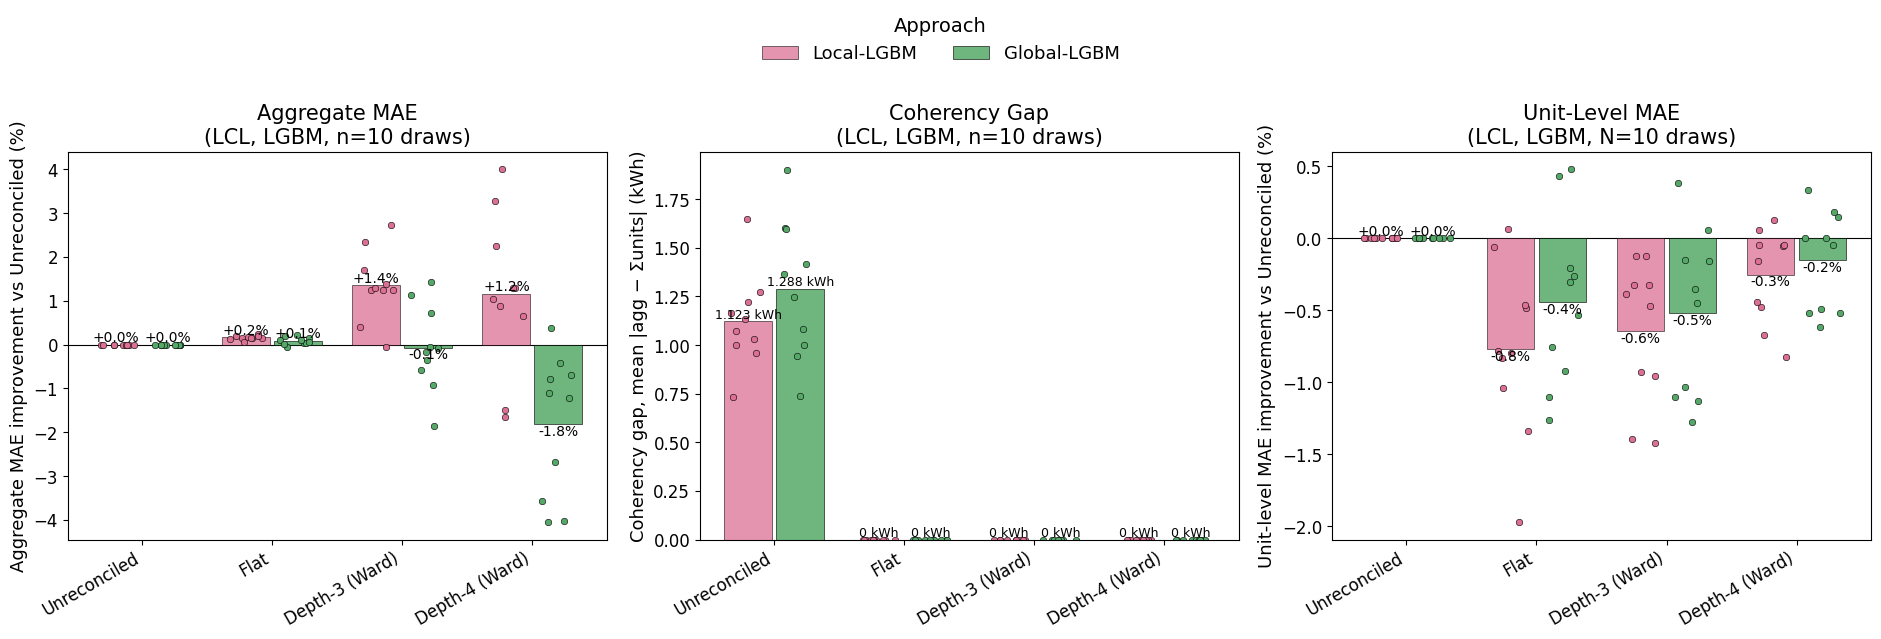

In [ ]:
# ── Step 8 — Figure: aggregate MAE, coherency gap, unit-level MAE across hierarchy depths ──
# Fixed color per approach (Global = green, Local = pink).
# Panel 3 (unit-level) is computed from metrics_draw_df (level=='unit'), matching
# the same per-draw-aggregated % improvement used in the manuscript tables —
# NOT a mean of individual per-unit ratios, which diverges from the tables.

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 13})

FILTER_MODEL = 'LGBM'
APPROACHES   = ['local', 'global']

UNIT_LABEL = 'kWh' if DATASET.lower() == 'lcl' else 'MWh'

METHODS       = ['flat', 'ward_depth3', 'ward_depth4']
METHOD_LABELS = {'flat': 'Flat', 'ward_depth3': 'Depth-3 (Ward)', 'ward_depth4': 'Depth-4 (Ward)'}
ALL_LABELS    = ['Unreconciled'] + [METHOD_LABELS[m] for m in METHODS]

GLOBAL_COLOR = '#55A868'   # green
LOCAL_COLOR  = '#DB7093'   # pink
APPROACH_COLOR = {'global': GLOBAL_COLOR, 'local': LOCAL_COLOR}
APPROACH_ALPHA = {'local': 0.75, 'global': 0.85}

rng = np.random.default_rng(RANDOM_SEED)

def jittered_x(center, n, width=0.10):
    return center + rng.uniform(-width, width, size=n)

n_cat = len(ALL_LABELS)
n_app = len(APPROACHES)
group_width = 0.8
bar_width = group_width / n_app
cat_x = np.arange(n_cat)

def offset_for(approach_idx):
    return (approach_idx - (n_app - 1) / 2) * bar_width

# ── Panel 1 data: aggregate MAE — % improvement vs Unreconciled, paired by draw ─
def get_panel1_data(approach):
    mdd_agg = metrics_draw_df[
        (metrics_draw_df['level']    == 'aggregate') &
        (metrics_draw_df['approach'] == approach) &
        (metrics_draw_df['model']    == FILTER_MODEL)
    ]
    unrec_draws_agg = mdd_agg[mdd_agg['cluster_method'] == 'flat'][['draw', 'mae_base']] \
        .rename(columns={'mae_base': 'value'}).set_index('draw')['value']

    draw_values = {'Unreconciled': np.zeros(len(unrec_draws_agg))}
    for m in METHODS:
        rec_series = (
            mdd_agg[mdd_agg['cluster_method'] == m][['draw', 'mae_rec']]
            .rename(columns={'mae_rec': 'value'}).set_index('draw')['value']
        )
        common_draws = unrec_draws_agg.index.intersection(rec_series.index)
        pct = (unrec_draws_agg.loc[common_draws] - rec_series.loc[common_draws]) \
              / unrec_draws_agg.loc[common_draws] * 100
        draw_values[METHOD_LABELS[m]] = pct.values
    means = [float(np.mean(draw_values[lbl])) for lbl in ALL_LABELS]
    return draw_values, means

# ── Panel 2 data: coherency gap — mean per method + per-draw values for jitter ─
def get_panel2_data(approach):
    ind_g = ind[(ind['approach'] == approach) & (ind['model'] == FILTER_MODEL)]
    agg_g = agg[agg['model'] == FILTER_MODEL]

    cg_unrec_per_draw = []
    for draw in draws:
        ind_d = ind_g[ind_g['draw'] == draw]
        agg_d = agg_g[agg_g['draw'] == draw]
        if ind_d.empty or agg_d.empty:
            continue
        bu = ind_d.groupby('timestamp')['y_pred'].sum()
        ap = agg_d.set_index('timestamp')['y_pred']
        common = bu.index.intersection(ap.index)
        if len(common) == 0:
            continue
        cg_unrec_per_draw.append(float(np.mean(np.abs(ap.loc[common] - bu.loc[common]))))
    cg_unrec_per_draw = np.array(cg_unrec_per_draw)
    cg_unrec = float(np.mean(cg_unrec_per_draw)) if len(cg_unrec_per_draw) else np.nan

    cg_sub = cg_df[(cg_df['approach'] == approach) & (cg_df['model'] == FILTER_MODEL)]

    draw_values = {'Unreconciled': cg_unrec_per_draw}
    for m in METHODS:
        draw_values[METHOD_LABELS[m]] = cg_sub[cg_sub['cluster_method'] == m]['cg_after'].values

    cg_rec_by_method = {m: cg_sub[cg_sub['cluster_method'] == m]['cg_after'].mean() for m in METHODS}
    values = [cg_unrec] + [cg_rec_by_method[m] for m in METHODS]
    return draw_values, values

# ── Panel 3 data: unit-level MAE — % improvement, paired by draw (matches Table 6/7) ─
def get_panel3_data(approach):
    mdd_unit = metrics_draw_df[
        (metrics_draw_df['level']    == 'unit') &
        (metrics_draw_df['approach'] == approach) &
        (metrics_draw_df['model']    == FILTER_MODEL)
    ]
    unrec_draws_unit = mdd_unit[mdd_unit['cluster_method'] == 'flat'][['draw', 'mae_base']] \
        .rename(columns={'mae_base': 'value'}).set_index('draw')['value']

    draw_values = {'Unreconciled': np.zeros(len(unrec_draws_unit))}
    for m in METHODS:
        rec_series = (
            mdd_unit[mdd_unit['cluster_method'] == m][['draw', 'mae_rec']]
            .rename(columns={'mae_rec': 'value'}).set_index('draw')['value']
        )
        common_draws = unrec_draws_unit.index.intersection(rec_series.index)
        pct = (unrec_draws_unit.loc[common_draws] - rec_series.loc[common_draws]) \
              / unrec_draws_unit.loc[common_draws] * 100
        draw_values[METHOD_LABELS[m]] = pct.values
    means = [float(np.mean(draw_values[lbl])) for lbl in ALL_LABELS]
    return draw_values, means

panel1_by_approach = {a: get_panel1_data(a) for a in APPROACHES}
panel2_by_approach = {a: get_panel2_data(a) for a in APPROACHES}
panel3_by_approach = {a: get_panel3_data(a) for a in APPROACHES}

def fmt_cg(v):
    if np.isnan(v):
        return 'n/a'
    if abs(v) < 1e-12:
        return f'0 {UNIT_LABEL}'
    if abs(v) >= 0.001:
        decimals = max(3, -int(np.floor(np.log10(abs(v)))) + 2)
        return f'{v:.{decimals}f} {UNIT_LABEL}'
    return f'{v:.3e} {UNIT_LABEL}'

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

ax = axes[0]
ax.axhline(0, color='black', linewidth=0.8, zorder=0)
for ai, approach in enumerate(APPROACHES):
    draw_values, means = panel1_by_approach[approach]
    off = offset_for(ai)
    color = APPROACH_COLOR[approach]
    ax.bar(cat_x + off, means, width=bar_width * 0.92, color=color,
           alpha=APPROACH_ALPHA[approach], edgecolor='black', linewidth=0.5,
           zorder=1, label=f'{approach.capitalize()}-{FILTER_MODEL}')
    for i, lbl in enumerate(ALL_LABELS):
        vals = draw_values[lbl]
        if len(vals) == 0:
            continue
        ax.scatter(jittered_x(cat_x[i] + off, len(vals), width=bar_width * 0.35),
                   vals, color=color, edgecolor='black', linewidth=0.4, s=22, zorder=2)
    for i, v in enumerate(means):
        va = 'bottom' if v >= 0 else 'top'
        ax.text(cat_x[i] + off, v, f'{v:+.1f}%', ha='center', va=va, fontsize=10)
ax.set_xticks(cat_x); ax.set_xticklabels(ALL_LABELS, rotation=30, ha='right', fontsize=12)
ax.set_ylabel('Aggregate MAE improvement vs Unreconciled (%)', fontsize=13)
ax.set_title(f'Aggregate MAE\n({DATASET.upper()}, {FILTER_MODEL}, n={len(draws)} draws)', fontsize=15)
ax.tick_params(axis='y', labelsize=12)

ax = axes[1]
for ai, approach in enumerate(APPROACHES):
    draw_values, values = panel2_by_approach[approach]
    off = offset_for(ai)
    color = APPROACH_COLOR[approach]
    ax.bar(cat_x + off, values, width=bar_width * 0.92, color=color,
           alpha=APPROACH_ALPHA[approach], edgecolor='black', linewidth=0.5,
           zorder=1, label=f'{approach.capitalize()}-{FILTER_MODEL}')
    for i, lbl in enumerate(ALL_LABELS):
        vals = draw_values[lbl]
        if len(vals) == 0:
            continue
        ax.scatter(jittered_x(cat_x[i] + off, len(vals), width=bar_width * 0.35),
                   vals, color=color, edgecolor='black', linewidth=0.4, s=22, zorder=2)
    for i, v in enumerate(values):
        ax.text(cat_x[i] + off, v, fmt_cg(v), ha='center', va='bottom', fontsize=9)
ax.set_xticks(cat_x); ax.set_xticklabels(ALL_LABELS, rotation=30, ha='right', fontsize=12)
ax.set_ylabel(f'Coherency gap, mean |agg − Σunits| ({UNIT_LABEL})', fontsize=13)
ax.set_title(f'Coherency Gap\n({DATASET.upper()}, {FILTER_MODEL}, n={len(draws)} draws)', fontsize=15)
ax.tick_params(axis='y', labelsize=12)

ax = axes[2]
ax.axhline(0, color='black', linewidth=0.8, zorder=0)
for ai, approach in enumerate(APPROACHES):
    draw_values, means = panel3_by_approach[approach]
    off = offset_for(ai)
    color = APPROACH_COLOR[approach]
    ax.bar(cat_x + off, means, width=bar_width * 0.92, color=color,
           alpha=APPROACH_ALPHA[approach], edgecolor='black', linewidth=0.5,
           zorder=1, label=f'{approach.capitalize()}-{FILTER_MODEL}')
    for i, lbl in enumerate(ALL_LABELS):
        vals = draw_values[lbl]
        if len(vals) == 0:
            continue
        ax.scatter(jittered_x(cat_x[i] + off, len(vals), width=bar_width * 0.35),
                   vals, color=color, edgecolor='black', linewidth=0.4, s=22, zorder=2)
    for i, v in enumerate(means):
        va = 'bottom' if v >= 0 else 'top'
        ax.text(cat_x[i] + off, v, f'{v:+.1f}%', ha='center', va=va, fontsize=10)
ax.set_xticks(cat_x); ax.set_xticklabels(ALL_LABELS, rotation=30, ha='right', fontsize=12)
ax.set_ylabel('Unit-level MAE improvement vs Unreconciled (%)', fontsize=13)
ax.set_title(f'Unit-Level MAE\n({DATASET.upper()}, {FILTER_MODEL}, N={len(draws)} draws)', fontsize=15)
ax.tick_params(axis='y', labelsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08),
           ncol=2, frameon=False, title='Approach', fontsize=13, title_fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(out_dir, f'fig_mae_cg_summary_{DATASET}_local_vs_global.png'),
            dpi=200, bbox_inches='tight')
plt.show()

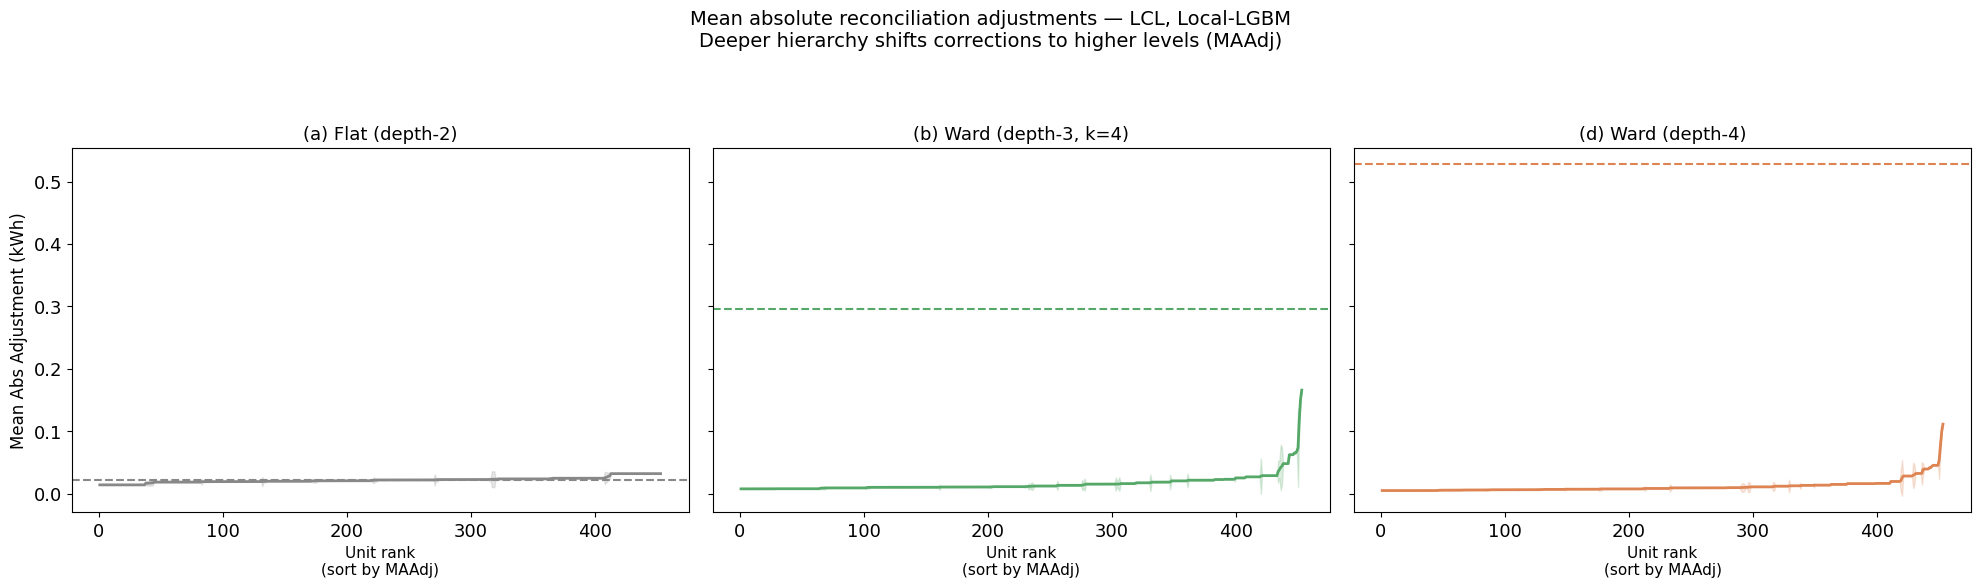

In [ ]:
# ── Figure: per-unit MAAdj, sorted, with aggregate-node reference line ────────
import matplotlib.pyplot as plt
import numpy as np

FILTER_APPROACH = 'local'
FILTER_MODEL    = 'LGBM'
UNIT_LABEL      = 'kWh' if DATASET.lower() == 'lcl' else 'MWh'

PANELS = [
    ('flat',        '(a) Flat (depth-2)',      '#888888'),
    ('ward_depth3', '(b) Ward (depth-3, k=4)', '#55A868'),
    #('kmeans_depth3','(c) k-means (depth-3, k=4)', '#4C72B0'),
    ('ward_depth4', '(d) Ward (depth-4)',      '#DD8452'),
]

fig, axes = plt.subplots(1, len(PANELS), figsize=(20, 6), sharey=True)

for ax, (method, title, color) in zip(axes, PANELS):
    # ── Unit-level: mean MAAdj per unit across draws, sorted ───────────────
    sub = maadj_df[
        (maadj_df['approach']       == FILTER_APPROACH) &
        (maadj_df['model']          == FILTER_MODEL) &
        (maadj_df['cluster_method'] == method)
    ]

    per_unit = (
        sub.groupby(ID)['maa']
        .agg(['mean', 'std'])
        .reset_index()
        .sort_values('mean')
        .reset_index(drop=True)
    )
    per_unit['rank'] = np.arange(1, len(per_unit) + 1)

    ax.plot(per_unit['rank'], per_unit['mean'], color=color, linewidth=2)
    ax.fill_between(
        per_unit['rank'],
        per_unit['mean'] - per_unit['std'].fillna(0),
        per_unit['mean'] + per_unit['std'].fillna(0),
        color=color, alpha=0.2
    )

    # ── Aggregate-node MAAdj (dashed reference line) ───────────────────────
    agg_maa = metrics_all[
        (metrics_all['level']         == 'aggregate') &
        (metrics_all['approach']      == FILTER_APPROACH) &
        (metrics_all['model']         == FILTER_MODEL) &
        (metrics_all['cluster_method']== method)
    ]['maa']

    if len(agg_maa) > 0:
        ax.axhline(agg_maa.values[0], color=color, linestyle='--', linewidth=1.5)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Unit rank\n(sort by MAAdj)', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel(f'Mean Abs Adjustment ({UNIT_LABEL})', fontsize=12)

fig.suptitle(
    f'Mean absolute reconciliation adjustments — {DATASET.upper()}, '
    f'{FILTER_APPROACH.capitalize()}-{FILTER_MODEL}\n'
    f'Deeper hierarchy shifts corrections to higher levels (MAAdj)',
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(out_dir, f'maadj_{DATASET}_{FILTER_APPROACH}_{FILTER_MODEL.lower()}.png'),
            dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
sub_flat = maadj_df[
    (maadj_df['approach']=='local') & (maadj_df['model']=='LGBM') &
    (maadj_df['cluster_method']=='flat') & (maadj_df['draw']==best_draw)
]
print(sub_flat[[ID,'maa']].sort_values('maa'))

          LCLid       maa
2402  MAC000068  0.020985
2401  MAC000046  0.020985
2412  MAC000580  0.020985
2423  MAC002385  0.020985
2403  MAC000079  0.020985
2406  MAC000230  0.020985
2404  MAC000112  0.020985
2437  MAC005026  0.020985
2448  MAC005549  0.020985
2422  MAC002255  0.020985
2407  MAC000266  0.020985
2425  MAC004404  0.020985
2433  MAC004784  0.020985
2408  MAC000274  0.020985
2436  MAC004977  0.020985
2428  MAC004500  0.020985
2439  MAC005227  0.020985
2416  MAC000708  0.020985
2438  MAC005213  0.020985
2431  MAC004537  0.020985
2426  MAC004465  0.020985
2443  MAC005349  0.020985
2442  MAC005329  0.020985
2424  MAC002455  0.020985
2432  MAC004738  0.020985
2421  MAC002248  0.020985
2413  MAC000591  0.020985
2446  MAC005525  0.020985
2414  MAC000674  0.020985
2418  MAC000915  0.020985
2445  MAC005514  0.020985
2434  MAC004885  0.020985
2419  MAC001012  0.020985
2427  MAC004494  0.020985
2440  MAC005246  0.020985
2430  MAC004534  0.020985
2447  MAC005529  0.020985
2405  MAC000

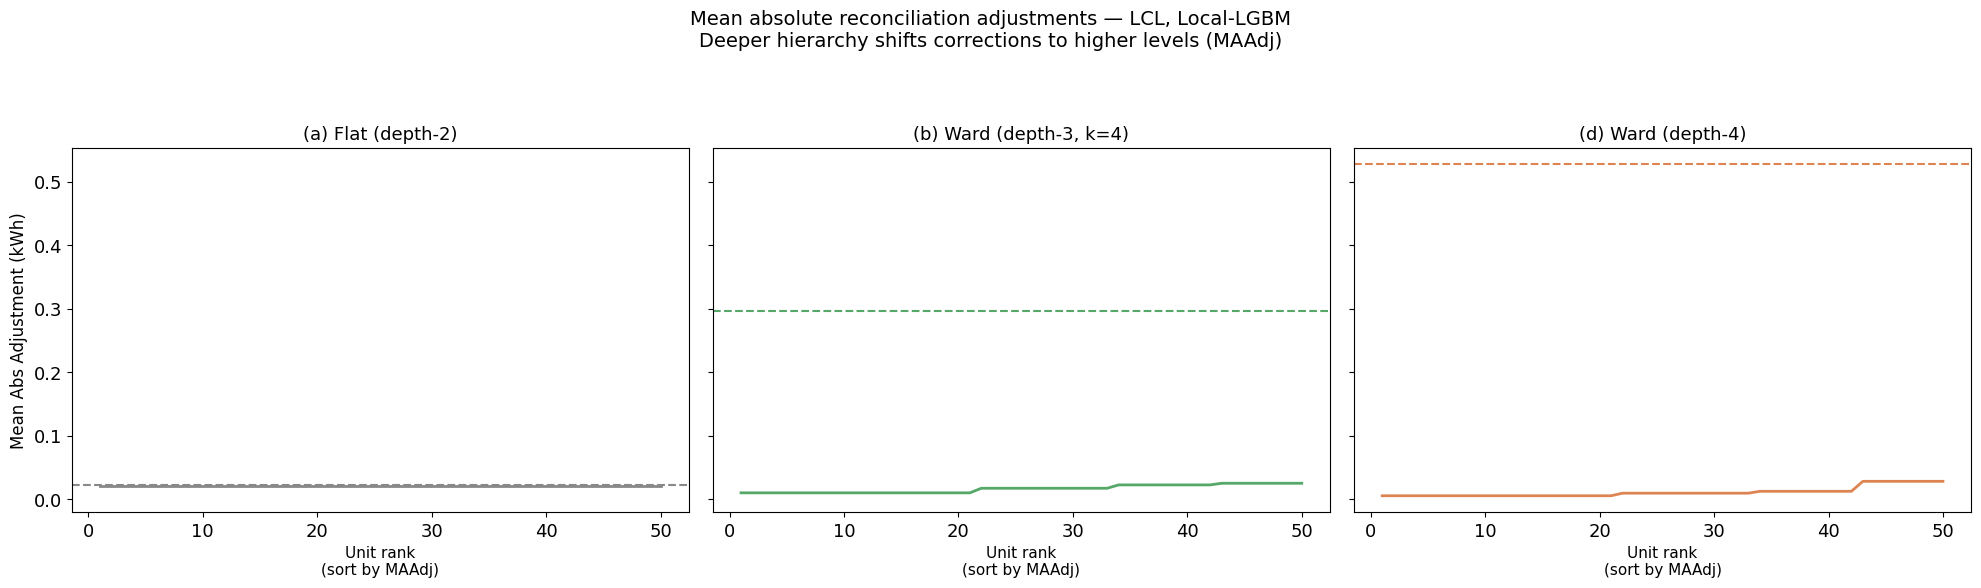

In [ ]:
# ── Figure: per-unit MAAdj, single representative draw ─────────────────────
import matplotlib.pyplot as plt
import numpy as np

FILTER_APPROACH = 'local'
FILTER_MODEL    = 'LGBM'
UNIT_LABEL      = 'kWh' if DATASET.lower() == 'lcl' else 'MWh'

PANELS = [
    ('flat',         '(a) Flat (depth-2)',         '#888888'),
    ('ward_depth3',  '(b) Ward (depth-3, k=4)',    '#55A868'),
  #  ('kmeans_depth3','(c) k-means (depth-3, k=4)', '#4C72B0'),
    ('ward_depth4',  '(d) Ward (depth-4)',         '#DD8452'),
]

fig, axes = plt.subplots(1, len(PANELS), figsize=(20, 6), sharey=True)

for ax, (method, title, color) in zip(axes, PANELS):
    sub = maadj_df[
        (maadj_df['approach']       == FILTER_APPROACH) &
        (maadj_df['model']          == FILTER_MODEL) &
        (maadj_df['cluster_method'] == method) &
        (maadj_df['draw']           == best_draw)   # ← single representative draw only
    ]

    per_unit = sub[[ID, 'maa']].sort_values('maa').reset_index(drop=True)
    per_unit['rank'] = np.arange(1, len(per_unit) + 1)

    ax.plot(per_unit['rank'], per_unit['maa'], color=color, linewidth=2)

    agg_maa = metrics_all[
        (metrics_all['level']          == 'aggregate') &
        (metrics_all['approach']       == FILTER_APPROACH) &
        (metrics_all['model']          == FILTER_MODEL) &
        (metrics_all['cluster_method'] == method)
    ]['maa']
    if len(agg_maa) > 0:
        ax.axhline(agg_maa.values[0], color=color, linestyle='--', linewidth=1.5)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Unit rank\n(sort by MAAdj)', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel(f'Mean Abs Adjustment ({UNIT_LABEL})', fontsize=12)

fig.suptitle(
    f'Mean absolute reconciliation adjustments — {DATASET.upper()}, '
    f'{FILTER_APPROACH.capitalize()}-{FILTER_MODEL}\n'
    f'Deeper hierarchy shifts corrections to higher levels (MAAdj)',
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(out_dir, f'maadj_{DATASET}_{FILTER_APPROACH}_{FILTER_MODEL.lower()}.png'),
            dpi=200, bbox_inches='tight')
plt.show()

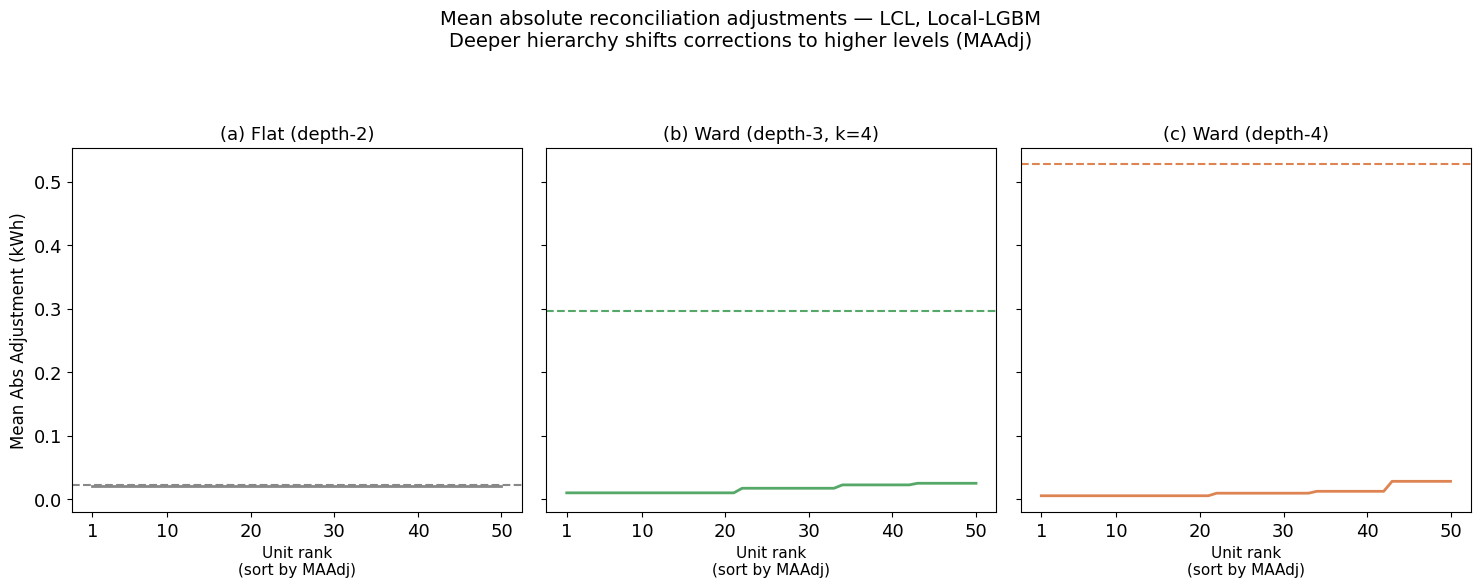

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

FILTER_APPROACH = 'local'
FILTER_MODEL    = 'LGBM'
UNIT_LABEL      = 'kWh' if DATASET.lower() == 'lcl' else 'MWh'

PANELS = [
    ('flat',        '(a) Flat (depth-2)',      '#888888'),
    ('ward_depth3', '(b) Ward (depth-3, k=4)', '#55A868'),
    ('ward_depth4', '(c) Ward (depth-4)',      '#DD8452'),
]

fig, axes = plt.subplots(1, len(PANELS), figsize=(15, 6), sharey=True)

for ax, (method, title, color) in zip(axes, PANELS):
    sub = maadj_df[
        (maadj_df['approach']       == FILTER_APPROACH) &
        (maadj_df['model']          == FILTER_MODEL) &
        (maadj_df['cluster_method'] == method) &
        (maadj_df['draw']           == best_draw)
    ]

    per_unit = sub[[ID, 'maa']].sort_values('maa').reset_index(drop=True)
    per_unit['rank'] = np.arange(1, len(per_unit) + 1)

    ax.plot(per_unit['rank'], per_unit['maa'], color=color, linewidth=2)

    agg_maa = metrics_all[
        (metrics_all['level']          == 'aggregate') &
        (metrics_all['approach']       == FILTER_APPROACH) &
        (metrics_all['model']          == FILTER_MODEL) &
        (metrics_all['cluster_method'] == method)
    ]['maa']
    if len(agg_maa) > 0:
        ax.axhline(agg_maa.values[0], color=color, linestyle='--', linewidth=1.5)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Unit rank\n(sort by MAAdj)', fontsize=11)
    ax.set_xticks([1, 10, 20, 30, 40, 50])
    if ax is axes[0]:
        ax.set_ylabel(f'Mean Abs Adjustment ({UNIT_LABEL})', fontsize=12)

fig.suptitle(
    f'Mean absolute reconciliation adjustments — {DATASET.upper()}, '
    f'{FILTER_APPROACH.capitalize()}-{FILTER_MODEL}\n'
    f'Deeper hierarchy shifts corrections to higher levels (MAAdj)',
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(out_dir, f'maadj_{DATASET}_{FILTER_APPROACH}_{FILTER_MODEL.lower()}.png'),
            dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
sub_flat = maadj_df[
    (maadj_df['approach']=='local') & (maadj_df['model']=='LGBM') &
    (maadj_df['cluster_method']=='flat') & (maadj_df['draw']==best_draw)
]
print(sub_flat[[ID,'maa']].sort_values('maa').to_string(index=False))

    LCLid      maa
MAC000068 0.020985
MAC000046 0.020985
MAC000580 0.020985
MAC002385 0.020985
MAC000079 0.020985
MAC000230 0.020985
MAC000112 0.020985
MAC005026 0.020985
MAC005549 0.020985
MAC002255 0.020985
MAC000266 0.020985
MAC004404 0.020985
MAC004784 0.020985
MAC000274 0.020985
MAC004977 0.020985
MAC004500 0.020985
MAC005227 0.020985
MAC000708 0.020985
MAC005213 0.020985
MAC004537 0.020985
MAC004465 0.020985
MAC005349 0.020985
MAC005329 0.020985
MAC002455 0.020985
MAC004738 0.020985
MAC002248 0.020985
MAC000591 0.020985
MAC005525 0.020985
MAC000674 0.020985
MAC000915 0.020985
MAC005514 0.020985
MAC004885 0.020985
MAC001012 0.020985
MAC004494 0.020985
MAC005246 0.020985
MAC004534 0.020985
MAC005529 0.020985
MAC000115 0.020985
MAC001038 0.020985
MAC000740 0.020985
MAC000332 0.020985
MAC005303 0.020985
MAC000350 0.020985
MAC004501 0.020985
MAC005434 0.020985
MAC004902 0.020985
MAC005553 0.020985
MAC000480 0.020985
MAC000692 0.020985
MAC000040 0.020985


In [ ]:
vi_check = val_ind_w[
    (val_ind_w['approach'] == 'local') &
    (val_ind_w['model']    == 'LGBM')
]
units_check = all_units_draw[best_draw]

for u in units_check:
    n_rows = len(vi_check[vi_check[ID] == u])
    print(f'{u}: {n_rows} val rows' + ('  <-- FALLBACK' if n_rows < 5 else ''))

MAC000040: 744 val rows
MAC000046: 744 val rows
MAC000068: 744 val rows
MAC000079: 744 val rows
MAC000112: 744 val rows
MAC000115: 1488 val rows
MAC000230: 744 val rows
MAC000266: 744 val rows
MAC000274: 744 val rows
MAC000332: 744 val rows
MAC000350: 1488 val rows
MAC000480: 2232 val rows
MAC000580: 744 val rows
MAC000591: 744 val rows
MAC000674: 744 val rows
MAC000692: 744 val rows
MAC000708: 1488 val rows
MAC000740: 744 val rows
MAC000915: 744 val rows
MAC001012: 744 val rows
MAC001038: 744 val rows
MAC002248: 744 val rows
MAC002255: 744 val rows
MAC002385: 744 val rows
MAC002455: 744 val rows
MAC004404: 744 val rows
MAC004465: 744 val rows
MAC004494: 744 val rows
MAC004500: 744 val rows
MAC004501: 744 val rows
MAC004534: 744 val rows
MAC004537: 744 val rows
MAC004738: 1488 val rows
MAC004784: 1488 val rows
MAC004885: 744 val rows
MAC004902: 744 val rows
MAC004977: 744 val rows
MAC005026: 744 val rows
MAC005213: 744 val rows
MAC005227: 744 val rows
MAC005246: 744 val rows
MAC005303:

In [ ]:
vi_check = val_ind_w[
    (val_ind_w['approach'] == 'local') &
    (val_ind_w['model']    == 'LGBM') &
    (val_ind_w['draw']     == best_draw)
]
units_check = all_units_draw[best_draw]

variances = {}
for u in units_check:
    u_sub = vi_check[vi_check[ID] == u]
    variances[u] = float(((u_sub['y_true'] - u_sub['y_pred'])**2).mean())

import pandas as pd
var_series = pd.Series(variances).sort_values()
print(var_series)
print(f'\nmax/min ratio: {var_series.max()/var_series.min():.3f}')
print(f'coefficient of variation: {var_series.std()/var_series.mean():.4f}')

MAC001012    0.003861
MAC004534    0.005184
MAC001038    0.006650
MAC005514    0.008728
MAC005525    0.009835
MAC000708    0.011962
MAC002255    0.012013
MAC005349    0.012271
MAC000674    0.013236
MAC004738    0.016190
MAC000591    0.019452
MAC000266    0.019613
MAC004977    0.023109
MAC005246    0.023378
MAC002248    0.024007
MAC004784    0.030519
MAC004500    0.030535
MAC004465    0.031013
MAC000915    0.031202
MAC000332    0.038333
MAC000115    0.039228
MAC004885    0.043499
MAC004494    0.046012
MAC005026    0.047731
MAC005213    0.048098
MAC000350    0.049413
MAC004537    0.052052
MAC002455    0.058851
MAC005529    0.060671
MAC005227    0.063154
MAC000046    0.072223
MAC004404    0.075935
MAC000740    0.076087
MAC000068    0.081639
MAC005329    0.089392
MAC005303    0.093607
MAC002385    0.108317
MAC005549    0.110673
MAC000079    0.119214
MAC004501    0.133961
MAC000274    0.138954
MAC000580    0.143815
MAC000230    0.154378
MAC000112    0.157677
MAC005434    0.182660
MAC004902 

In [ ]:
# Theoretical per-unit weight, given real variance heterogeneity
var_series = var_series.sort_index()  # match units order if needed
theoretical_weight = var_series / var_series.sum()

print('Theoretical weight (should predict relative adjustment size):')
print(theoretical_weight.sort_values(ascending=False))

# Compare: does MAC005406 (variance 2.48, weight ~66%) actually get
# a much larger share of correction than MAC002469 (variance 0.003, weight ~0.08%)?

Theoretical weight (should predict relative adjustment size):
MAC000692    0.110761
MAC000480    0.089438
MAC000040    0.081384
MAC005553    0.078810
MAC004902    0.050827
MAC005434    0.041074
MAC000112    0.035456
MAC000230    0.034715
MAC000580    0.032339
MAC000274    0.031246
MAC004501    0.030123
MAC000079    0.026808
MAC005549    0.024887
MAC002385    0.024357
MAC005303    0.021049
MAC005329    0.020101
MAC000068    0.018358
MAC000740    0.017110
MAC004404    0.017075
MAC000046    0.016241
MAC005227    0.014201
MAC005529    0.013643
MAC002455    0.013234
MAC004537    0.011705
MAC000350    0.011111
MAC005213    0.010816
MAC005026    0.010733
MAC004494    0.010347
MAC004885    0.009782
MAC000115    0.008821
MAC000332    0.008620
MAC000915    0.007016
MAC004465    0.006974
MAC004500    0.006866
MAC004784    0.006863
MAC002248    0.005398
MAC005246    0.005257
MAC004977    0.005196
MAC000266    0.004410
MAC000591    0.004374
MAC004738    0.003641
MAC000674    0.002976
MAC005349    0

In [ ]:
# ── Step 4: Reconciliation loop (with debug prints for Wb/P investigation) ────
import time

metrics_rows   = []
timing_records = []
maadj_store    = {}
coherency_gaps = []

np.random.seed(RANDOM_SEED)

# ── DEBUG TARGET — change these if you want to check a different case ─────────
DEBUG_DRAW     = best_draw
DEBUG_APPROACH = 'local'
DEBUG_MODEL    = 'LGBM'

for approach in ['local', 'global']:
    ind_sub = ind[ind['approach'] == approach]

    for mname in sorted(ind['model'].unique()):
        ind_m = ind_sub[ind_sub['model'] == mname]
        agg_m = agg[agg['model'] == mname]

        for draw in tqdm(draws, desc=f'{approach}/{mname}'):

            ind_d = ind_m[ind_m['draw'] == draw]
            agg_d = agg_m[agg_m['draw'] == draw]

            common_ts = np.intersect1d(
                ind_d['timestamp'].unique(),
                agg_d['timestamp'].unique()
            )
            if len(common_ts) == 0: continue

            ind_d = ind_d[ind_d['timestamp'].isin(common_ts)]
            agg_d = agg_d[agg_d['timestamp'].isin(common_ts)]

            units = all_units_draw[draw]
            n     = len(units)
            if n < 4: continue

            fine_map          = all_fine_maps[draw]
            coarse_map        = all_coarse_maps[draw]
            rand_map          = all_rand_maps[draw]
            kmeans_fine_map   = all_kmeans_fine_maps[draw]
            kmeans_coarse_map = all_kmeans_coarse_maps[draw]

            val_d = val_ind_w[
                (val_ind_w['draw'] == draw) &
                (val_ind_w[ID].isin(units))
            ]
            Wb = estimate_Wb(val_d, units, approach, mname)

            # ── DEBUG CHECK 1: Wb right after estimation ───────────────────────
            is_debug_case = (draw == DEBUG_DRAW and approach == DEBUG_APPROACH and mname == DEBUG_MODEL)
            if is_debug_case:
                print('=' * 70)
                print(f'DEBUG: draw={draw}, approach={approach}, model={mname}')
                print('=' * 70)
                print('units order:', units)
                print('Wb diagonal (should match var_series computed manually):')
                print(np.diag(Wb))
                print(f'Wb diag min/max: {np.diag(Wb).min():.6f} / {np.diag(Wb).max():.6f}')
                print(f'Wb diag ratio: {np.diag(Wb).max()/np.diag(Wb).min():.3f}')

            S_matrices = {
                'flat':          build_S_flat(units),
                'ward_depth3':   build_S_depth3(units, fine_map),
                'ward_depth4':   build_S_depth4(units, coarse_map, fine_map),
                'kmeans_depth3': build_S_depth3(units, kmeans_fine_map),
                'kmeans_depth4': build_S_depth4(units, kmeans_coarse_map, kmeans_fine_map),
                'random':        build_S_depth3(units, rand_map),
            }

            ts_sorted   = sorted(common_ts)
            ind_pivot   = (
                ind_d.set_index(['timestamp', ID])['y_pred']
                .unstack(ID).reindex(columns=units).loc[ts_sorted]
            )
            true_pivot  = (
                ind_d.set_index(['timestamp', ID])['y_true']
                .unstack(ID).reindex(columns=units).loc[ts_sorted]
            )
            agg_pred_ts = agg_d.set_index('timestamp')['y_pred'].reindex(ts_sorted)
            agg_true_ts = agg_d.set_index('timestamp')['y_true'].reindex(ts_sorted)

            valid = (
                ind_pivot.notna().all(axis=1) &
                true_pivot.notna().all(axis=1) &
                agg_pred_ts.notna() &
                agg_true_ts.notna()
            )
            if valid.sum() == 0: continue

            ind_pivot   = ind_pivot[valid].values
            true_pivot  = true_pivot[valid].values
            agg_pred    = agg_pred_ts[valid].values
            agg_true    = agg_true_ts[valid].values

            T = ind_pivot.shape[0]

            mae_agg_base  = float(np.mean(np.abs(agg_true - agg_pred)))
            mae_unit_base = float(np.mean(np.abs(true_pivot - ind_pivot)))

            for s_name, S in S_matrices.items():

                if s_name == 'flat':
                    Yhat_base  = np.column_stack([agg_pred, ind_pivot])
                    Ytrue_base = np.column_stack([agg_true, true_pivot])
                    unit_offset = 1

                elif s_name in ('ward_depth4', 'kmeans_depth4'):
                    cmap = coarse_map if s_name == 'ward_depth4' else kmeans_coarse_map
                    fmap = fine_map   if s_name == 'ward_depth4' else kmeans_fine_map
                    coarse_cls = sorted(set(cmap.values()))
                    fine_cls   = sorted(set(fmap.values()))
                    unit_idx   = {u: i for i, u in enumerate(units)}
                    cp = np.column_stack([
                        ind_pivot[:, [unit_idx[u] for u in units if cmap[u]==c]].sum(axis=1)
                        for c in coarse_cls])
                    ct = np.column_stack([
                        true_pivot[:, [unit_idx[u] for u in units if cmap[u]==c]].sum(axis=1)
                        for c in coarse_cls])
                    fp = np.column_stack([
                        ind_pivot[:, [unit_idx[u] for u in units if fmap[u]==f]].sum(axis=1)
                        for f in fine_cls])
                    ft = np.column_stack([
                        true_pivot[:, [unit_idx[u] for u in units if fmap[u]==f]].sum(axis=1)
                        for f in fine_cls])
                    Yhat_base   = np.column_stack([agg_pred, cp, fp, ind_pivot])
                    Ytrue_base  = np.column_stack([agg_true, ct, ft, true_pivot])
                    unit_offset = 1 + len(coarse_cls) + len(fine_cls)

                else:
                    cmap = (fine_map        if s_name == 'ward_depth3'   else
                            kmeans_fine_map  if s_name == 'kmeans_depth3' else
                            rand_map)
                    cls      = sorted(set(cmap.values()))
                    unit_idx = {u: i for i, u in enumerate(units)}
                    clp = np.column_stack([
                        ind_pivot[:, [unit_idx[u] for u in units if cmap[u]==c]].sum(axis=1)
                        for c in cls])
                    clt = np.column_stack([
                        true_pivot[:, [unit_idx[u] for u in units if cmap[u]==c]].sum(axis=1)
                        for c in cls])
                    Yhat_base   = np.column_stack([agg_pred, clp, ind_pivot])
                    Ytrue_base  = np.column_stack([agg_true, clt, true_pivot])
                    unit_offset = 1 + len(cls)

                # ── DEBUG CHECK 2: P matrix for the flat case specifically ─────
                if is_debug_case and s_name == 'flat':
                    print()
                    print(f'--- s_name={s_name} ---')
                    print('S shape:', S.shape, ' Wb shape:', Wb.shape)
                    print('Wb diag right before mint_wls:', np.diag(Wb))
                    W_full_dbg = S @ Wb @ S.T + RIDGE * np.eye(S.shape[0])
                    W_inv_dbg  = np.linalg.pinv(W_full_dbg)
                    inner_dbg  = S.T @ W_inv_dbg @ S
                    P_dbg      = S @ np.linalg.solve(inner_dbg, S.T @ W_inv_dbg)
                    print('P matrix, unit-to-unit block (diagonal should vary a lot):')
                    print(np.round(np.diag(P_dbg[1:, 1:]), 6))
                    print('P matrix, unit-to-unit block, off-diagonal sample (row 0):')
                    print(np.round(P_dbg[1, 1:], 6))

                t0       = time.perf_counter()
                Yhat_rec = mint_wls(Yhat_base, S, Wb, ridge=RIDGE)
                t_rec    = time.perf_counter() - t0

                # ── DEBUG CHECK 3: actual adjustments right after mint_wls ─────
                if is_debug_case and s_name == 'flat':
                    adj_check = Yhat_rec[:, 1:1+n] - ind_pivot
                    maa_check = np.mean(np.abs(adj_check), axis=0)
                    print('Actual per-unit MAAdj from Yhat_rec (should match theoretical weights):')
                    print(dict(zip(units, np.round(maa_check, 6))))

                timing_records.append({
                    'draw': draw, 'model': mname, 'approach': approach,
                    'cluster_method': s_name,
                    'n_units': n, 'n_timestamps': T,
                    'S_rows': S.shape[0], 'S_cols': S.shape[1],
                    'time_reconcile_s': round(t_rec, 6),
                })

                rec_agg   = Yhat_rec[:, 0]
                rec_units = Yhat_rec[:, unit_offset:unit_offset + n]
                tru_units = Ytrue_base[:, unit_offset:unit_offset + n]

                mae_agg_rec  = float(np.mean(np.abs(agg_true - rec_agg)))
                mae_unit_rec = float(np.mean(np.abs(tru_units - rec_units)))

                maa_agg  = float(np.mean(np.abs(rec_agg   - agg_pred)))
                maa_unit = float(np.mean(np.abs(rec_units - ind_pivot)))

                per_unit_maa = {u: float(np.mean(np.abs(rec_units[:, i] - ind_pivot[:, i])))
                                for i, u in enumerate(units)}

                cg_after = float(np.mean(np.abs(rec_agg - rec_units.sum(axis=1))))

                key = (draw, approach, mname, s_name)
                maadj_store[key] = per_unit_maa

                coherency_gaps.append({
                    'draw': draw, 'approach': approach,
                    'model': mname, 'cluster_method': s_name,
                    'cg_after': cg_after
                })

                metrics_rows.append({
                    'draw': draw, 'approach': approach, 'model': mname,
                    'cluster_method': s_name, 'level': 'aggregate',
                    'mae_base': round(mae_agg_base,  4),
                    'mae_rec':  round(mae_agg_rec,   4),
                    'mae_change': round(mae_agg_rec - mae_agg_base, 4),
                    'maa': round(maa_agg, 4),
                })

                metrics_rows.append({
                    'draw': draw, 'approach': approach, 'model': mname,
                    'cluster_method': s_name, 'level': 'unit',
                    'mae_base': round(mae_unit_base, 4),
                    'mae_rec':  round(mae_unit_rec,  4),
                    'mae_change': round(mae_unit_rec - mae_unit_base, 4),
                    'maa': round(maa_unit, 4),
                })

print(f'Metric rows       : {len(metrics_rows):,}')
print(f'Timing records    : {len(timing_records):,}')
print(f'Coherency checks  : {len(coherency_gaps):,}')
print(f'MAAdj draw keys   : {len(maadj_store):,}')
print(f'Expected metric rows: {len(draws) * 2 * 2 * 6 * 2}  (draws×approaches×models×methods×levels)')

local/LGBM:   0%|          | 0/10 [00:00<?, ?it/s]/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: divide by zero encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: overflow encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: invalid value encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_ma

DEBUG: draw=8, approach=local, model=LGBM
units order: ['MAC000040', 'MAC000046', 'MAC000068', 'MAC000079', 'MAC000112', 'MAC000115', 'MAC000230', 'MAC000266', 'MAC000274', 'MAC000332', 'MAC000350', 'MAC000480', 'MAC000580', 'MAC000591', 'MAC000674', 'MAC000692', 'MAC000708', 'MAC000740', 'MAC000915', 'MAC001012', 'MAC001038', 'MAC002248', 'MAC002255', 'MAC002385', 'MAC002455', 'MAC004404', 'MAC004465', 'MAC004494', 'MAC004500', 'MAC004501', 'MAC004534', 'MAC004537', 'MAC004738', 'MAC004784', 'MAC004885', 'MAC004902', 'MAC004977', 'MAC005026', 'MAC005213', 'MAC005227', 'MAC005246', 'MAC005303', 'MAC005329', 'MAC005349', 'MAC005434', 'MAC005514', 'MAC005525', 'MAC005529', 'MAC005549', 'MAC005553']
Wb diagonal (should match var_series computed manually):
[0.36192016 0.07222278 0.08163875 0.1192143  0.15767672 0.03922841
 0.15437799 0.01961271 0.13895364 0.03833313 0.04941255 0.39773727
 0.1438149  0.01945158 0.01323606 0.49256073 0.01196229 0.07608729
 0.03120211 0.00386054 0.00665022 0.


local/LR:   0%|          | 0/10 [00:00<?, ?it/s]/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: divide by zero encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: overflow encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_54304/2421068454.py:170: RuntimeWarning: invalid value encountered in matmul
  W_full = S @ Wb @ S.T + ridge * np.eye(M)   # single ridge here only
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_mat

Metric rows       : 480
Timing records    : 240
Coherency checks  : 240
MAAdj draw keys   : 240
Expected metric rows: 480  (draws×approaches×models×methods×levels)
